# Lab 7- Data Analysis


## Exercise 1: Reading

### HiggsML
In 2014, some of my colleagues from the ATLAS experiment put together a Higgs Machine Learning Challenge, which was hosted on [Kaggle](https://www.kaggle.com). Please read sections 1 and 3 (skip/skim 2) of [The HiggsML Technical Documentation](https://higgsml.lal.in2p3.fr/files/2014/04/documentation_v1.8.pdf). 

Kaggle is a platform for data science competitions, with cash awards for winners. Kaggle currently hosts over 50,000 public datasets and associated competitions. Later in the course we will look at a variety of problems hosted on Kaggle and similar platforms. 

### SUSY Dataset

For the next few labs we will use datasets used in the [first paper on Deep Learning in High Energy physics](https://arxiv.org/pdf/1402.4735.pdf). Please read up to the "Deep Learning" section (end of page 5). This paper demonstrates that Deep Neural Networks can learn from raw data the features that are typically used by physicists for searches for exotics particles. The authors provide the data they used for this paper. They considered two benchmark scenarios: Higgs and SUSY.

## Exercise 2: Download SUSY Dataset

The information about the dataset can be found at the [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/index.php). We'll start with the [SUSY Dataset](https://archive.ics.uci.edu/ml/datasets/SUSY). 

### Download
In a terminal, download the data directly from the source and then decompress it. For example:

* To download:
    * On Mac OS: 
    `curl http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz > SUSY.csv.gz`

    * In linux:
    `wget http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz`

* To uncompress:
`gunzip SUSY.csv.gz`

In [1]:
!curl http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz > SUSY.csv.gz

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  879M    0  879M    0     0  29.5M      0 --:--:--  0:00:29 --:--:-- 32.8M


In [2]:
!rm SUSY.csv

In [3]:
!gunzip SUSY.csv.gz

In [4]:
ls -lh

total 2.5G
-rw-rw-r-- 1 ashish ashish  75K Apr  3 21:04 Lab.7.Solutions.ipynb
-rw-rw-r-- 1 ashish ashish 390K Mar 19 14:11 Lab.7.ipynb
-rw-rw-r-- 1 ashish ashish 5.9M Mar 19 14:11 Lab.7.pdf
-rw-rw-r-- 1 ashish ashish 228M Apr  3 15:34 SUSY-small.csv
-rw-rw-r-- 1 ashish ashish 2.3G Apr  3 21:05 SUSY.csv


The data is provided as a comma separated file.

In [5]:
filename="SUSY.csv"
# print out the first 5 lines using unix head command
!head -5  "SUSY.csv"

0.000000000000000000e+00,9.728614687919616699e-01,6.538545489311218262e-01,1.176224589347839355e+00,1.157156467437744141e+00,-1.739873170852661133e+00,-8.743090629577636719e-01,5.677649974822998047e-01,-1.750000417232513428e-01,8.100607395172119141e-01,-2.525521218776702881e-01,1.921887040138244629e+00,8.896374106407165527e-01,4.107718467712402344e-01,1.145620822906494141e+00,1.932632088661193848e+00,9.944640994071960449e-01,1.367815494537353516e+00,4.071449860930442810e-02
1.000000000000000000e+00,1.667973041534423828e+00,6.419061869382858276e-02,-1.225171446800231934e+00,5.061022043228149414e-01,-3.389389812946319580e-01,1.672542810440063477e+00,3.475464344024658203e+00,-1.219136357307434082e+00,1.295456290245056152e-02,3.775173664093017578e+00,1.045977115631103516e+00,5.680512785911560059e-01,4.819284379482269287e-01,0.000000000000000000e+00,4.484102725982666016e-01,2.053557634353637695e-01,1.321893453598022461e+00,3.775840103626251221e-01
1.000000000000000000e+00,4.4483992457389831

## Reducing the dataset

This is a rather large dataset. If you have trouble loading it, we can easily make a new file with less data.

Here we look at the size of the data

In [6]:
!ls -lh

total 2.5G
-rw-rw-r-- 1 ashish ashish  75K Apr  3 21:04 Lab.7.Solutions.ipynb
-rw-rw-r-- 1 ashish ashish 390K Mar 19 14:11 Lab.7.ipynb
-rw-rw-r-- 1 ashish ashish 5.9M Mar 19 14:11 Lab.7.pdf
-rw-rw-r-- 1 ashish ashish 228M Apr  3 15:34 SUSY-small.csv
-rw-rw-r-- 1 ashish ashish 2.3G Apr  3 21:05 SUSY.csv


We see that we have 5 million datapoints.

In [7]:
!wc -l SUSY.csv

5000000 SUSY.csv


We create a new file of the first half million. This is sufficient for our needs in this lab:

In [8]:
!head -500000 SUSY.csv > SUSY-small.csv

In [9]:
ls -lh

total 2.5G
-rw-rw-r-- 1 ashish ashish  75K Apr  3 21:04 Lab.7.Solutions.ipynb
-rw-rw-r-- 1 ashish ashish 390K Mar 19 14:11 Lab.7.ipynb
-rw-rw-r-- 1 ashish ashish 5.9M Mar 19 14:11 Lab.7.pdf
-rw-rw-r-- 1 ashish ashish 228M Apr  3 21:05 SUSY-small.csv
-rw-rw-r-- 1 ashish ashish 2.3G Apr  3 21:05 SUSY.csv


In [10]:
! wc -l SUSY-small.csv

500000 SUSY-small.csv


Use this file for the rest of the lab to make this run faster.

### First Look

Each row represents a LHC collision event. Each column contains some observable from that event. The variable names are ([based on documentation](https://archive.ics.uci.edu/ml/datasets/SUSY)):

In [11]:
VarNames=["signal", "l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", "MET", "MET_phi", "MET_rel", "axial_MET", "M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]

Some of these variables represent the "raw" kinematics of the observed final state particles, while others are "features" that are derived from these raw quantities:

In [12]:
RawNames=["l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", "MET", "MET_phi"]
FeatureNames=list(set(VarNames[1:]).difference(RawNames))

In [13]:
RawNames

['l_1_pT',
 'l_1_eta',
 'l_1_phi',
 'l_2_pT',
 'l_2_eta',
 'l_2_phi',
 'MET',
 'MET_phi']

In [14]:
FeatureNames

['MT2',
 'M_R',
 'axial_MET',
 'S_R',
 'R',
 'M_Delta_R',
 'cos_theta_r1',
 'M_TR_2',
 'dPhi_r_b',
 'MET_rel']

We will use pandas to read in the file, and matplotlib to make plots. The following ensures pandas is installed and sets everything up:

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

Now we can read the data into a pandas dataframe:

In [16]:
filename = "SUSY-small.csv"
df = pd.read_csv(filename, dtype='float64', names=VarNames)

You can see the data in Jupyter by just evaluateing the dataframe:

In [17]:
df

,signal,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi,MET_rel,axial_MET,M_R,M_TR_2,R,MT2,S_R,M_Delta_R,dPhi_r_b,cos_theta_r1
0,0.0,0.972861,0.653855,1.176225,1.157156,-1.739873,-0.874309,0.567765,-0.175000,0.810061,-0.252552,1.921887,0.889637,0.410772,1.145621,1.932632,0.994464,1.367815,0.040714
1,1.0,1.667973,0.064191,-1.225171,0.506102,-0.338939,1.672543,3.475464,-1.219136,0.012955,3.775174,1.045977,0.568051,0.481928,0.000000,0.448410,0.205356,1.321893,0.377584
2,1.0,0.444840,-0.134298,-0.709972,0.451719,-1.613871,-0.768661,1.219918,0.504026,1.831248,-0.431385,0.526283,0.941514,1.587535,2.024308,0.603498,1.562374,1.135454,0.180910
3,1.0,0.381256,-0.976145,0.693152,0.448959,0.891753,-0.677328,2.033060,1.533041,3.046260,-1.005285,0.569386,1.015211,1.582217,1.551914,0.761215,1.715464,1.492257,0.090719
4,1.0,1.309996,-0.690089,-0.676259,1.589283,-0.693326,0.622907,1.087562,-0.381742,0.589204,1.365479,1.179295,0.968218,0.728563,0.000000,1.083158,0.043429,1.154854,0.094859
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499995,0.0,0.719035,1.091879,0.291540,1.205962,-1.599117,-1.139445,0.424546,1.154849,0.637185,-0.091178,1.972156,0.697028,0.313636,0.988602,1.981573,0.744828,1.095080,0.006546
499996,1.0,0.910016,-0.364544,-0.777120,0.543648,-0.910632,-1.723707,2.864673,1.458272,2.176558,-0.590911,0.673695,1.662140,2.189362,1.195041,0.910815,1.181893,1.252362,0.826035
499997,1.0,0.842954,0.332476,-1.048564,1.347989,0.320496,-0.666358,0.450433,-0.411872,0.293407,0.630491,0.859920,0.403371,0.416258,0.591989,0.372003,0.716788,0.366991,0.265798
499998,0.0,1.370760,-1.162912,0.893499,2.118091,1.248496,-0.887211,0.164659,0.316840,0.215165,0.280418,3.087083,0.526929,0.151467,0.308067,3.098183,0.233042,0.876216,0.000593


The first column stores the "truth" label of whether an event was signal or not. Pandas makes it easy to create dataframes that store only the signal or background events:

In [18]:
df_sig=df[df.signal==1]
df_bkg=df[df.signal==0]

The following example plots the signal and background distributions of every variable. Note that we use VarNames[1:] to skip the first variable, which was the true label.

l_1_pT


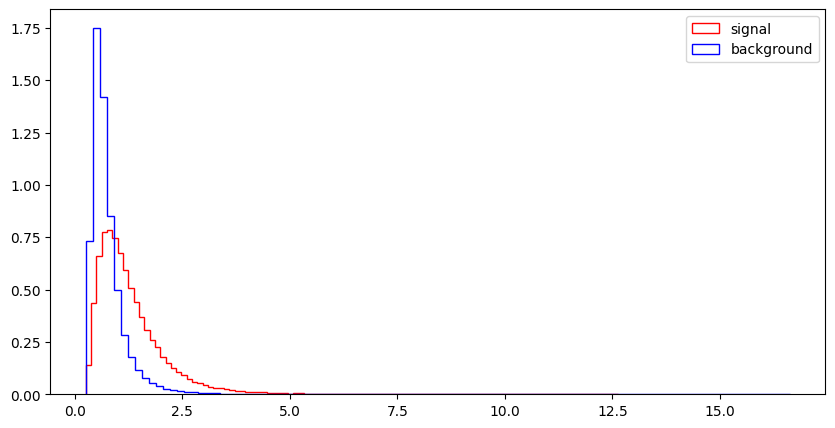

l_1_eta


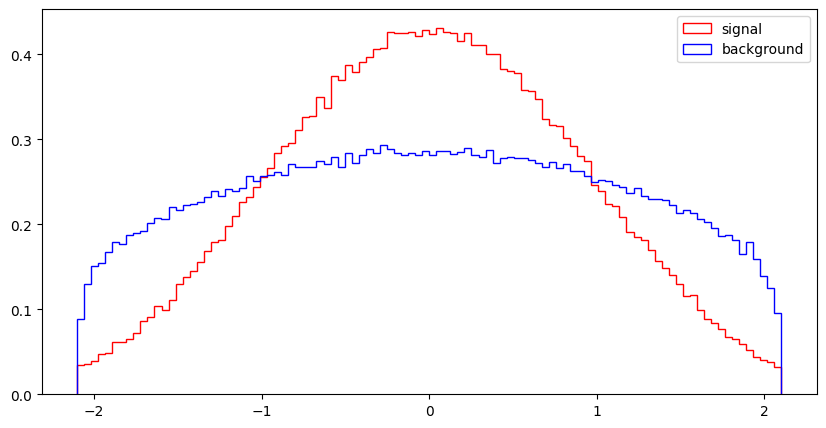

l_1_phi


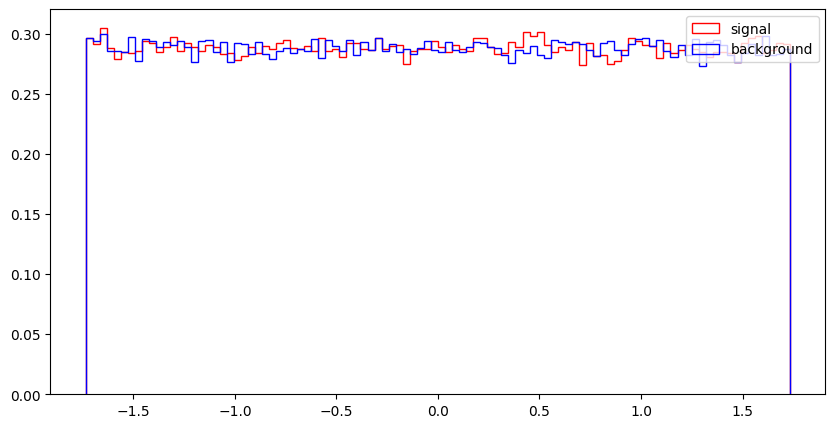

l_2_pT


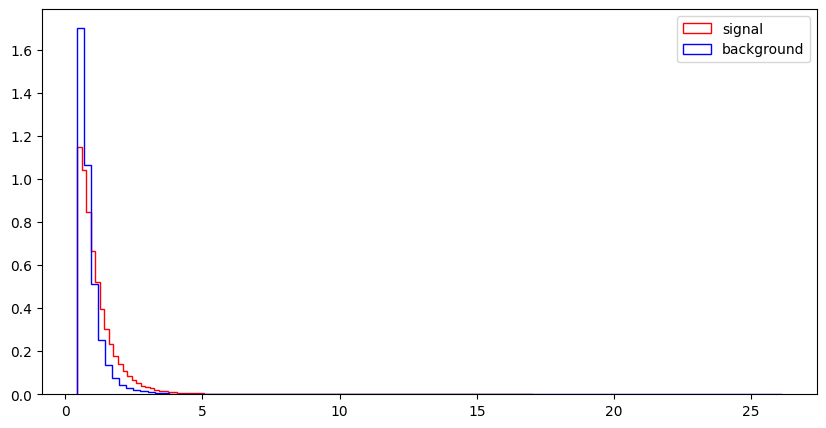

l_2_eta


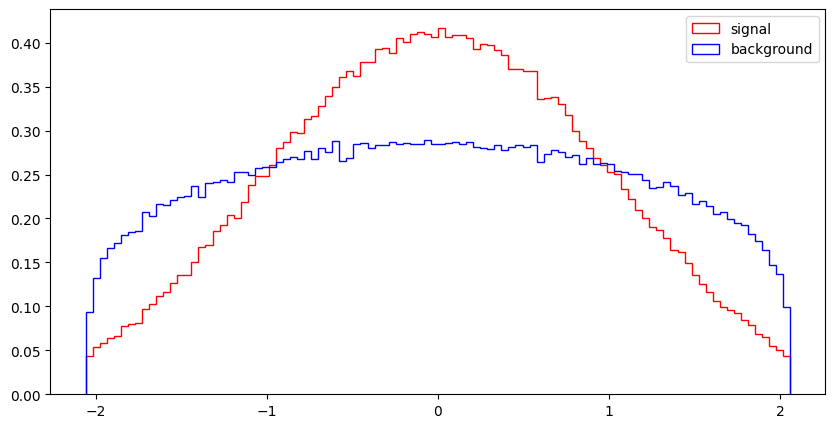

l_2_phi


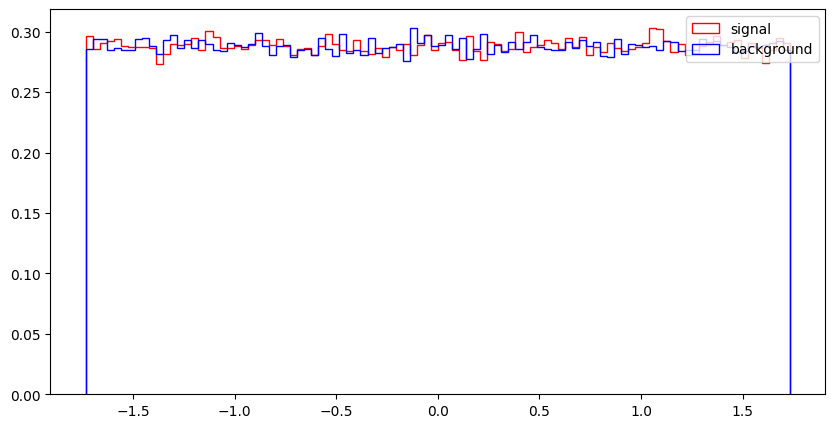

MET


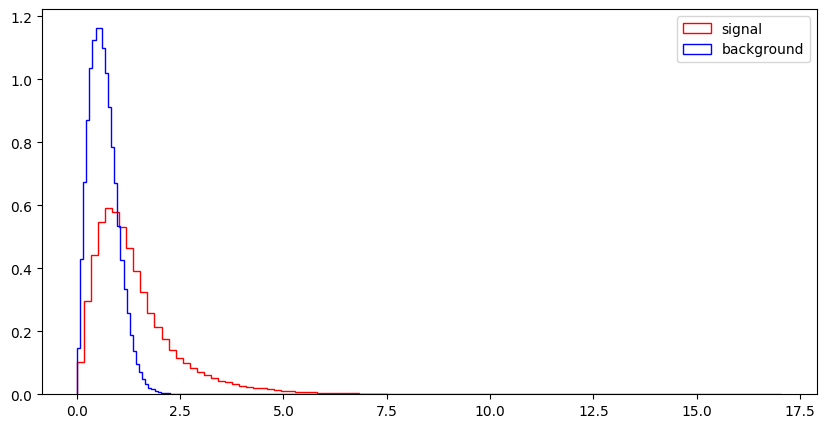

MET_phi


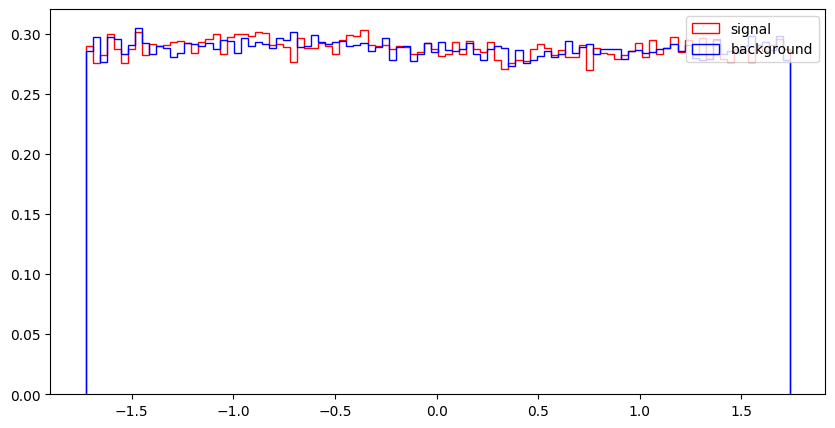

MET_rel


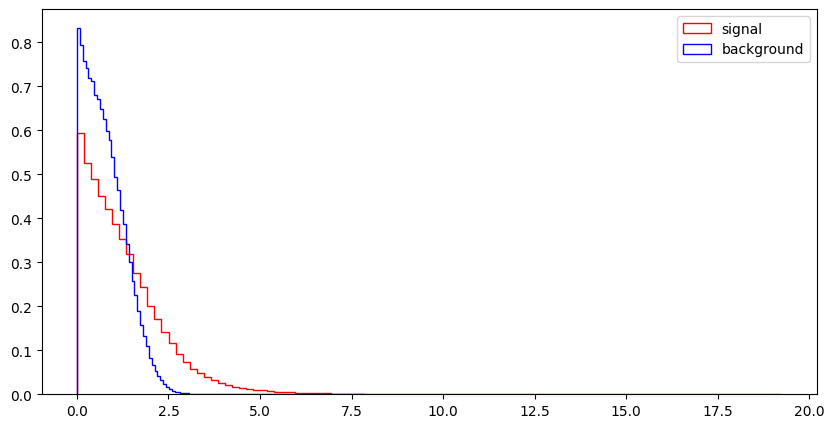

axial_MET


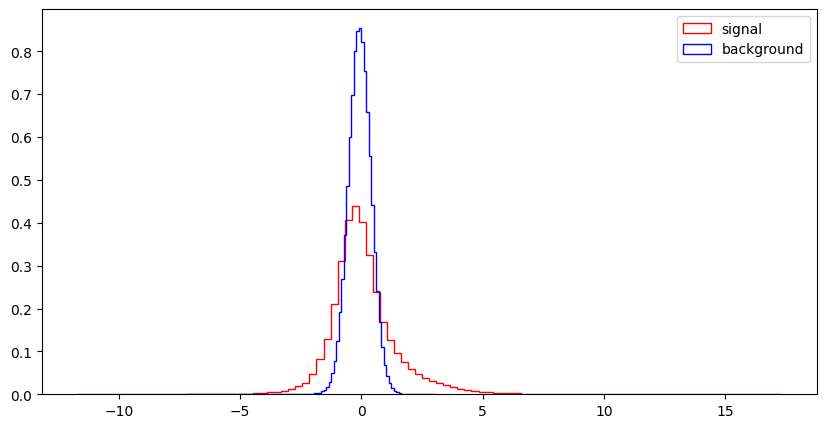

M_R


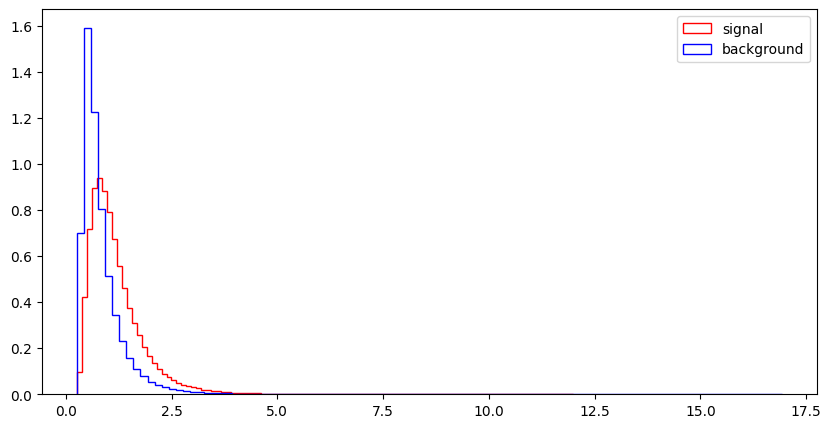

M_TR_2


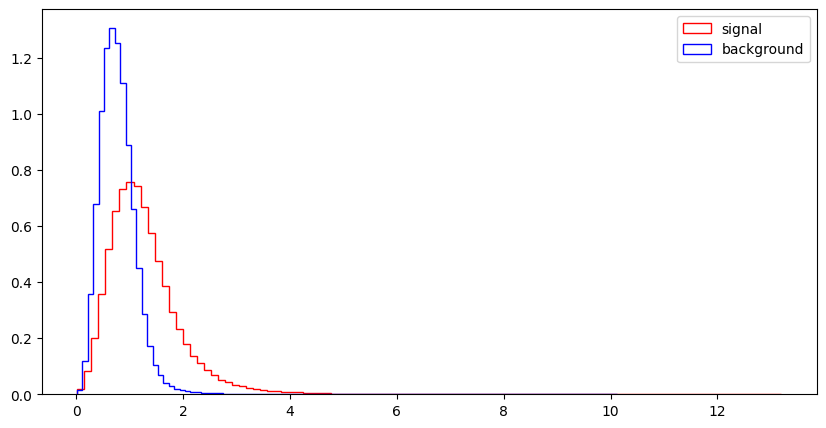

R


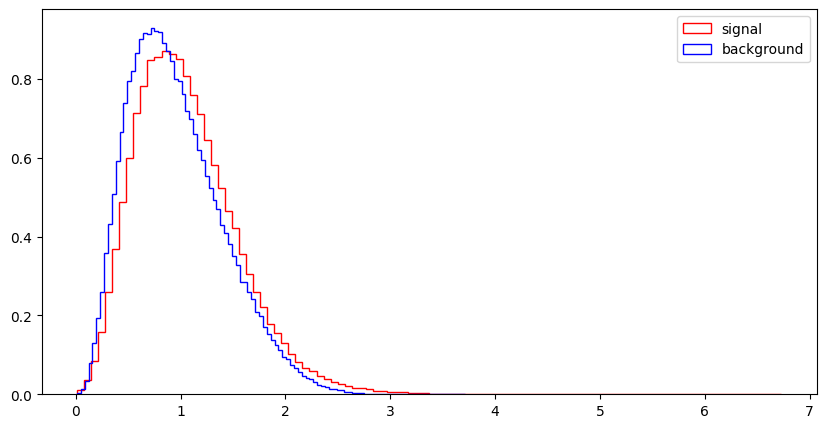

MT2


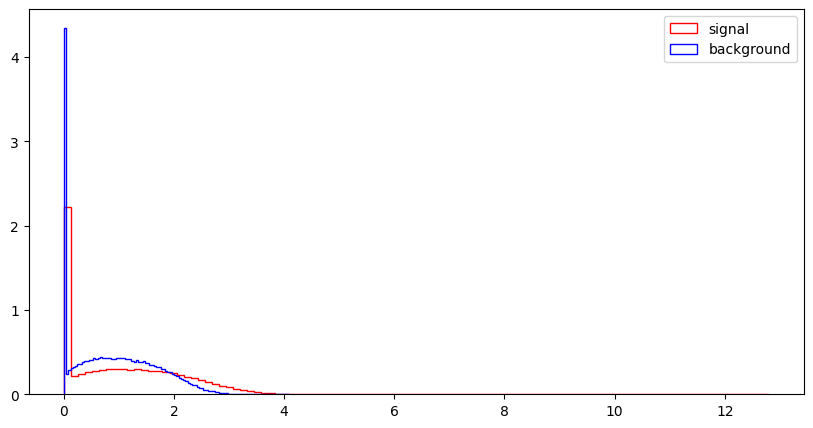

S_R


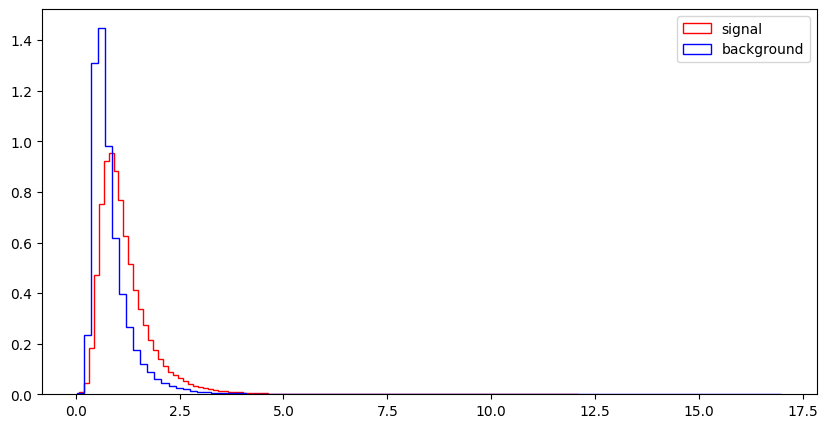

M_Delta_R


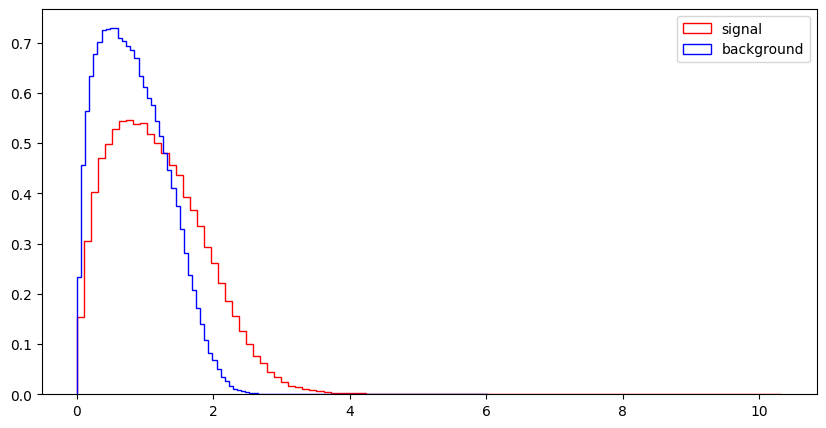

dPhi_r_b


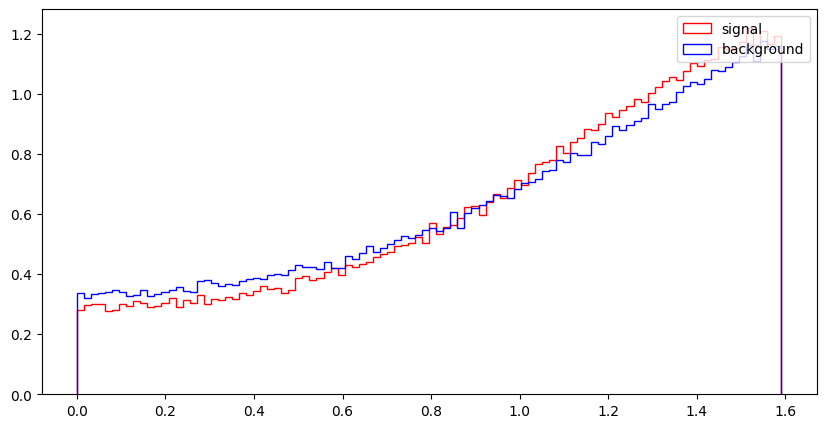

cos_theta_r1


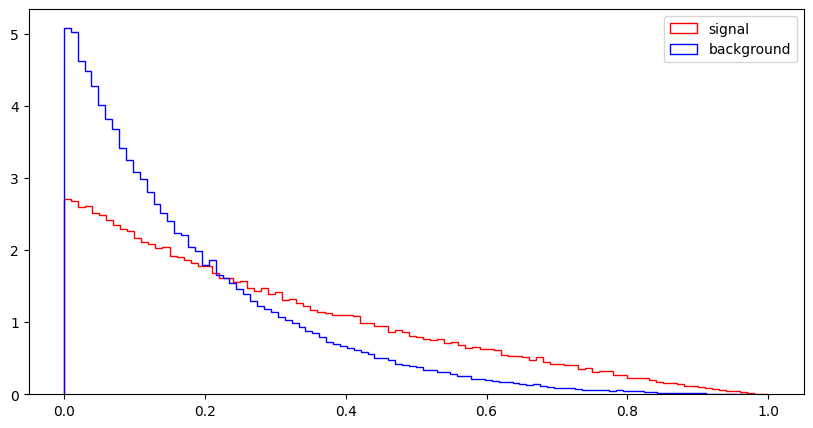

In [19]:
import numpy as np
for var in VarNames[1:]:
    print (var)
    plt.figure(figsize=(10,5))
    plt.hist(np.array(df_sig[var]),bins=100,histtype="step", color="red",label="signal",density=1, stacked=True)
    plt.hist(np.array(df_bkg[var]),bins=100,histtype="step", color="blue", label="background",density=1, stacked=True)
    plt.legend(loc='upper right')
    plt.show()

## Exercise 3: Make nice figures

Now use `matplotlib` to reproduce as closely as you can figures 5 and 6 from the paper. This exercise is intended to get you to familiarize yourself with making nicely formatted `matplotlib` figures with multiple plots. Note that the plots in the paper are actually wrong!

`NOTE:` For figure 5 (of the paper) I only choose 3 variables that were present in both dataset and the plot displayed in the paper.

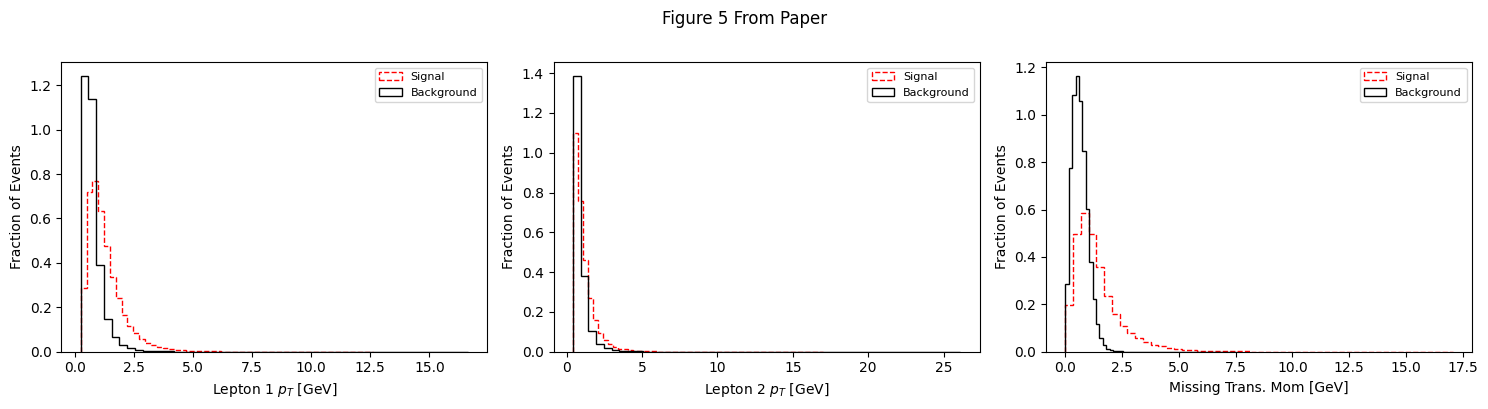

In [20]:
#Create a variable that holds the variable name with its corresponding desired x-label
#Label name supports LaTeX math notation: (wrapped in $...$) for formatted axis titles.
plot_vars= [
    ("l_1_pT", "Lepton 1 $p_T$ [GeV]"),
    ("l_2_pT", "Lepton 2 $p_T$ [GeV]"),
    ("MET",    "Missing Trans. Mom [GeV]")
]    #First element in each tuple is the variable and second element is the label for that variable

fig, axes= plt.subplots(1,3, figsize=(15,4))    #Creates a grid of subplots (1 rows and 3 columns)

#Loops for each subplot with its corresponding (variable, label) pair
for ax, (var, xlabel) in zip(axes, plot_vars):    #zip pairs each axis with corresponding (variable, label)
    
    #Red dash-lined Density Histogram with 50 bins for corresponding variable when signal
    ax.hist(df_sig[var], bins=50, density= True, histtype='step', color='red', label='Signal', linestyle='--')
    
    #Black lined Density Histogram with 50 bins for corresponding variable when Background
    ax.hist(df_bkg[var], bins=50, density= True, histtype='step', color='black', label='Background')
    ax.set_xlabel(xlabel)    #Sets label for x-axis (second element of every tuple in plot_var)
    ax.set_ylabel("Fraction of Events")   #Set label for y-axis
    ax.legend(fontsize=8)     #Displays colors represenration for the categories
plt.suptitle("Figure 5 From Paper", y=1.01)
plt.tight_layout()   #Prevents title and plot overlapping
plt.show()    #Displays the plot

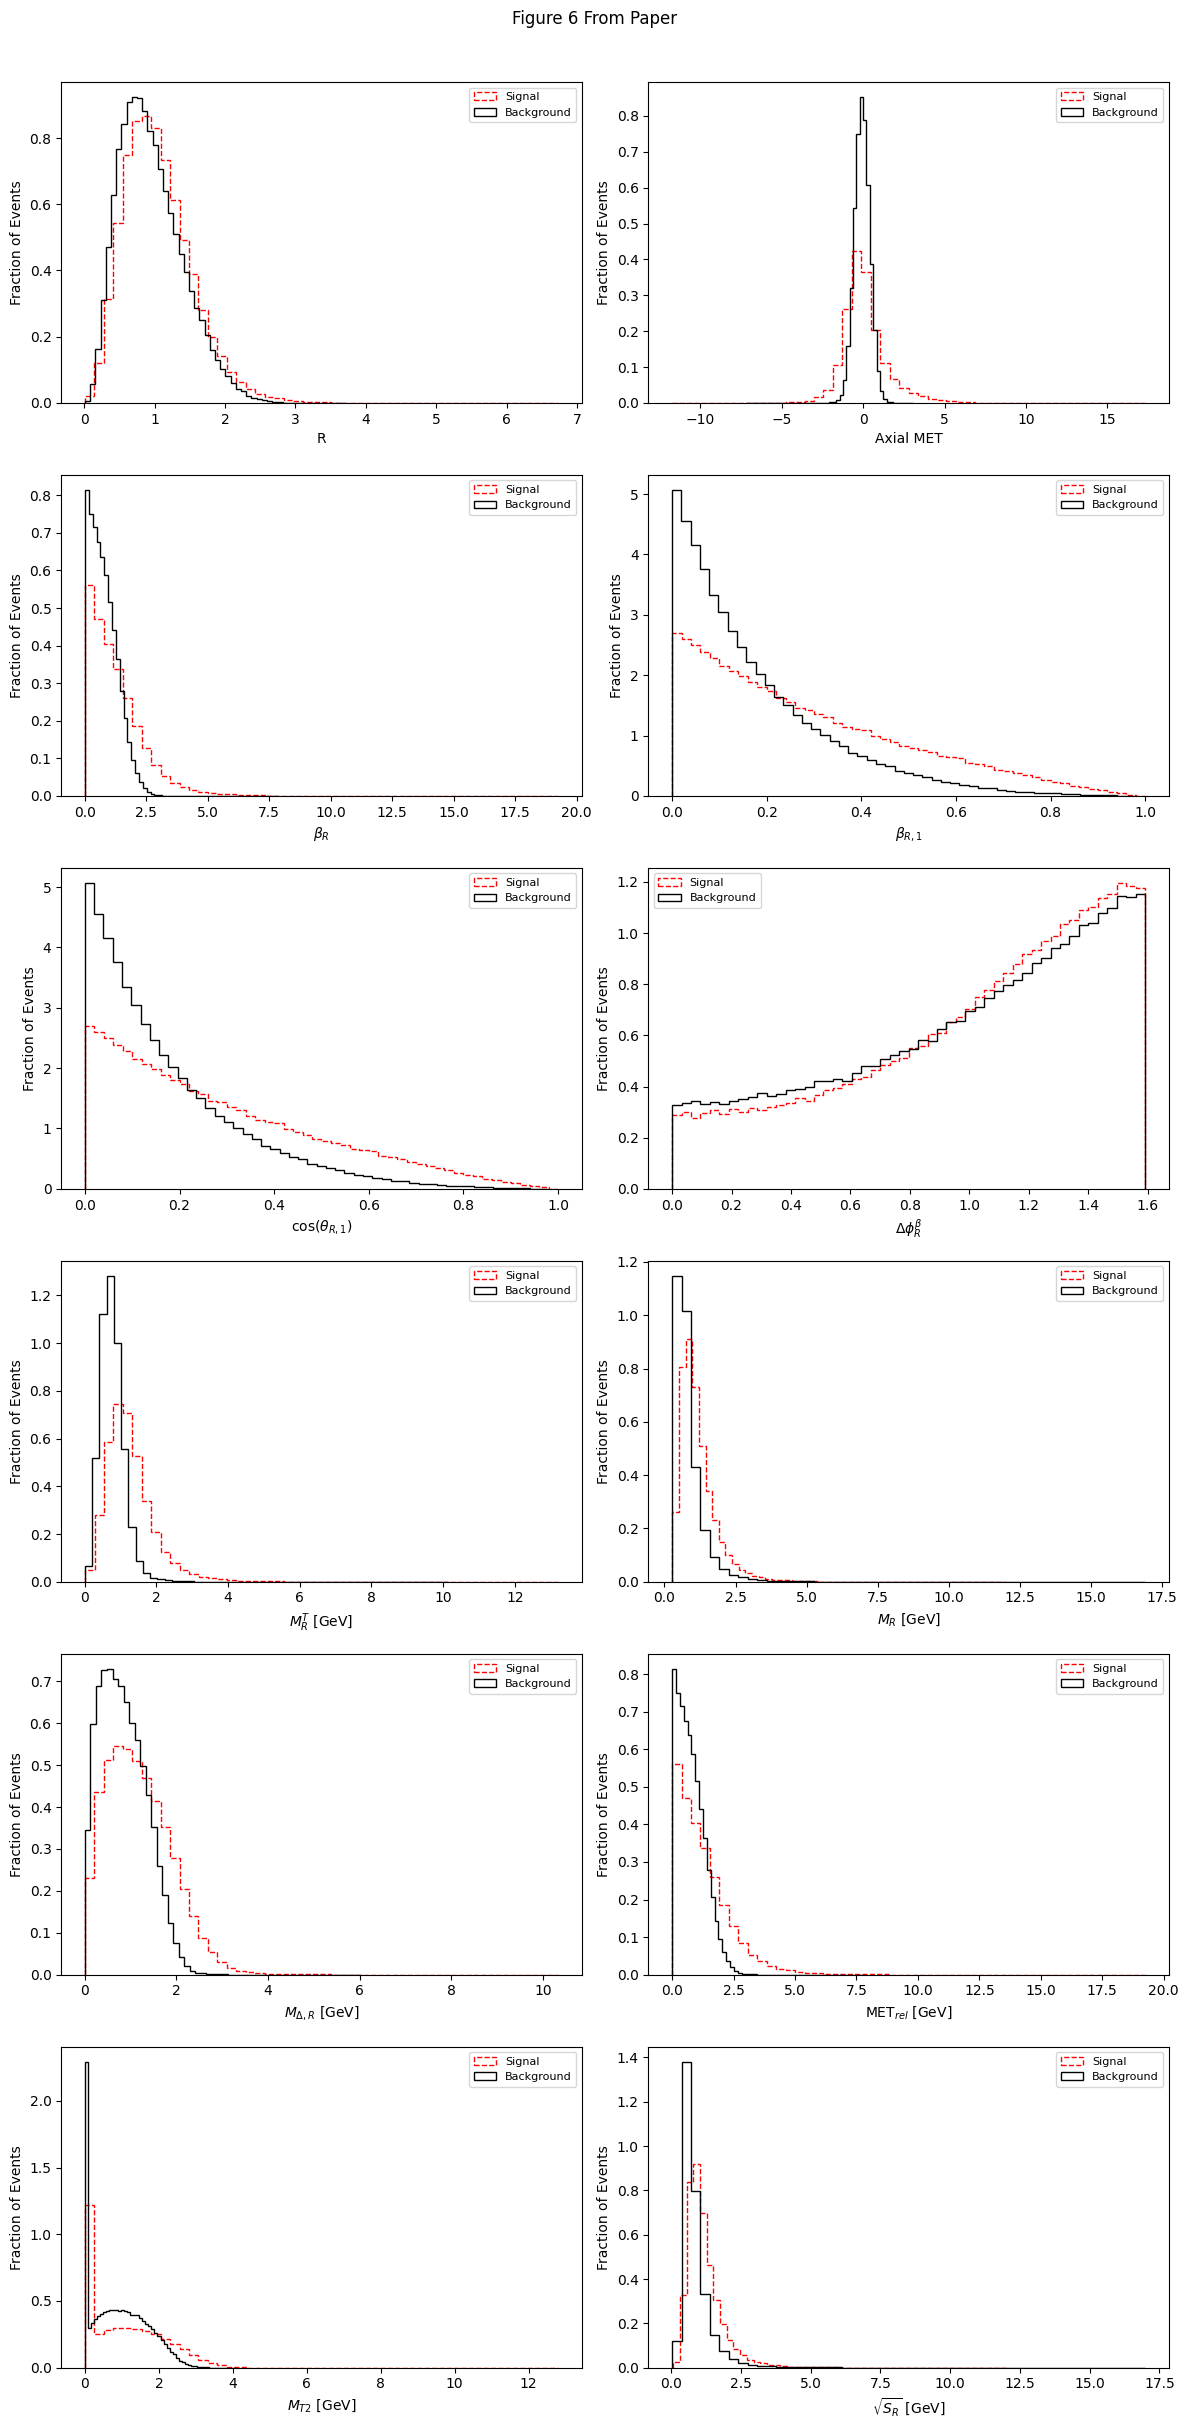

In [21]:
# Each tuple is (dataframe_column, desired_label)
#Label name supports LaTeX math notation: (wrapped in $...$) for formatted axis titles.
plot_vars_fig6 = [
    ("R",           "R"),
    ("axial_MET",   "Axial MET"),
    ("MET_rel",     "$\\beta_R$"),
    ("cos_theta_r1","$\\beta_{R,1}$"),
    ("cos_theta_r1","$\\cos(\\theta_{R,1})$"),
    ("dPhi_r_b",    "$\\Delta\\phi_R^{\\beta}$"),
    ("M_TR_2",      "$M_R^T$ [GeV]"),
    ("M_R",         "$M_R$ [GeV]"),
    ("M_Delta_R",   "$M_{\\Delta,R}$ [GeV]"),
    ("MET_rel",     "MET$_{rel}$ [GeV]"),
    ("MT2",         "$M_{T2}$ [GeV]"),
    ("S_R",         "$\\sqrt{S_R}$ [GeV]"),
]

#Creates a grid of subplots (6 rows and 2 columns)
fig, axes = plt.subplots(6, 2, figsize=(12, 24))
axes = axes.flatten()    #Converts 2D grid to 1D grid for easier looping (single loop instead of nested)

#Loops for each subplot with its corresponding (variable, label) pair
for ax, (var, xlabel) in zip(axes, plot_vars_fig6):    #zip pairs each axis with corresponding (variable, label)
    
    #Red dash-lined Density Histogram with 50 bins for corresponding variable when signal
    ax.hist(df_sig[var],     bins=50, density=True, histtype='step', linestyle='dashed', color='red',   label='Signal')
    
    #Black lined Density Histogram with 50 bins for corresponding variable when Background
    ax.hist(df_bkg[var], bins=50, density=True, histtype='step', color='black', label='Background')
    
    ax.set_xlabel(xlabel)    #Set x-label
    ax.set_ylabel("Fraction of Events")    #set y-label
    ax.legend(fontsize=8)    #Displays legend with font-size of 8 units

plt.suptitle("Figure 6 From Paper", y=1.01)
plt.tight_layout()
plt.show()    #Display plot

`NOTE:` AI was used for the better representation of the labels using the **LaTeX math format**.

## Exercise 4: Correlation

### Exercise 4.1

#### Part a
Write a function that creates pair plots and use it to compare variables in the SUSY sample, separately for low and high-level features. Refer to Lecture 13 for details. Do not use `seaborn`.

#### Part b
Making these plots can be slow because creating each plot initiates a full loop over the data. Make at least one modification to your function in part a to speed it up. Can you propose a different method of creating histograms that would speed up making such pair plots?

#### Part c
Which observables appear to be best for separating signal from background?

In [22]:
# Part a


#Create a function that takes dataframe, variable_names, and title of the plot and plots the corresponding pair-plot.
def pair_plot(df, varnames, title="Pair Plot"):
    n= len(varnames)    # number of variables passed in the argument
    
    #Creates a grid of subplots (n rows and n columns), each of size 2.5*2.5
    fig, axes= plt.subplots(n, n, figsize=(2.5*n, 2.5*n))
    
    #Provide the title for the plot with a font size of 14 units
    fig.suptitle(title, fontsize=16, y=1.01)    #y=1.01 sets the title slightly above its default value preventing the overlapping of plot and title

    for i, var_y in enumerate(varnames):    #Loop through variable with its corresponding index
        for j, var_x in enumerate(varnames):    #Loop through same variable with its index  
            ax= axes[i][j]    #subplot form 2-D sxes, at ith rows and jth column.
            
            #If the subplot is in leading diagonal (i==j) create a 1-D histogram for the variable for both 'signal' and 'background'
            if i==j:
                ax.hist(df_sig[var_x], bins=30, density=True, histtype='step', color='red', linestyle='--', label='Signal')
                ax.hist(df_bkg[var_x], bins=30, density=True, histtype='step', color='black', label='Background')
                ax.set_xlabel(var_x, fontsize=7)
                
            #Else, create a 2-D histogram for each variable plotted against one aother.
            else:
                ax.hist2d(df[var_x], df[var_y], bins=30, cmap="Blues")
                ax.set_xlabel(var_x, fontsize=7)
                ax.set_ylabel(var_y, fontsize=7)


    plt.tight_layout()
    plt.show()

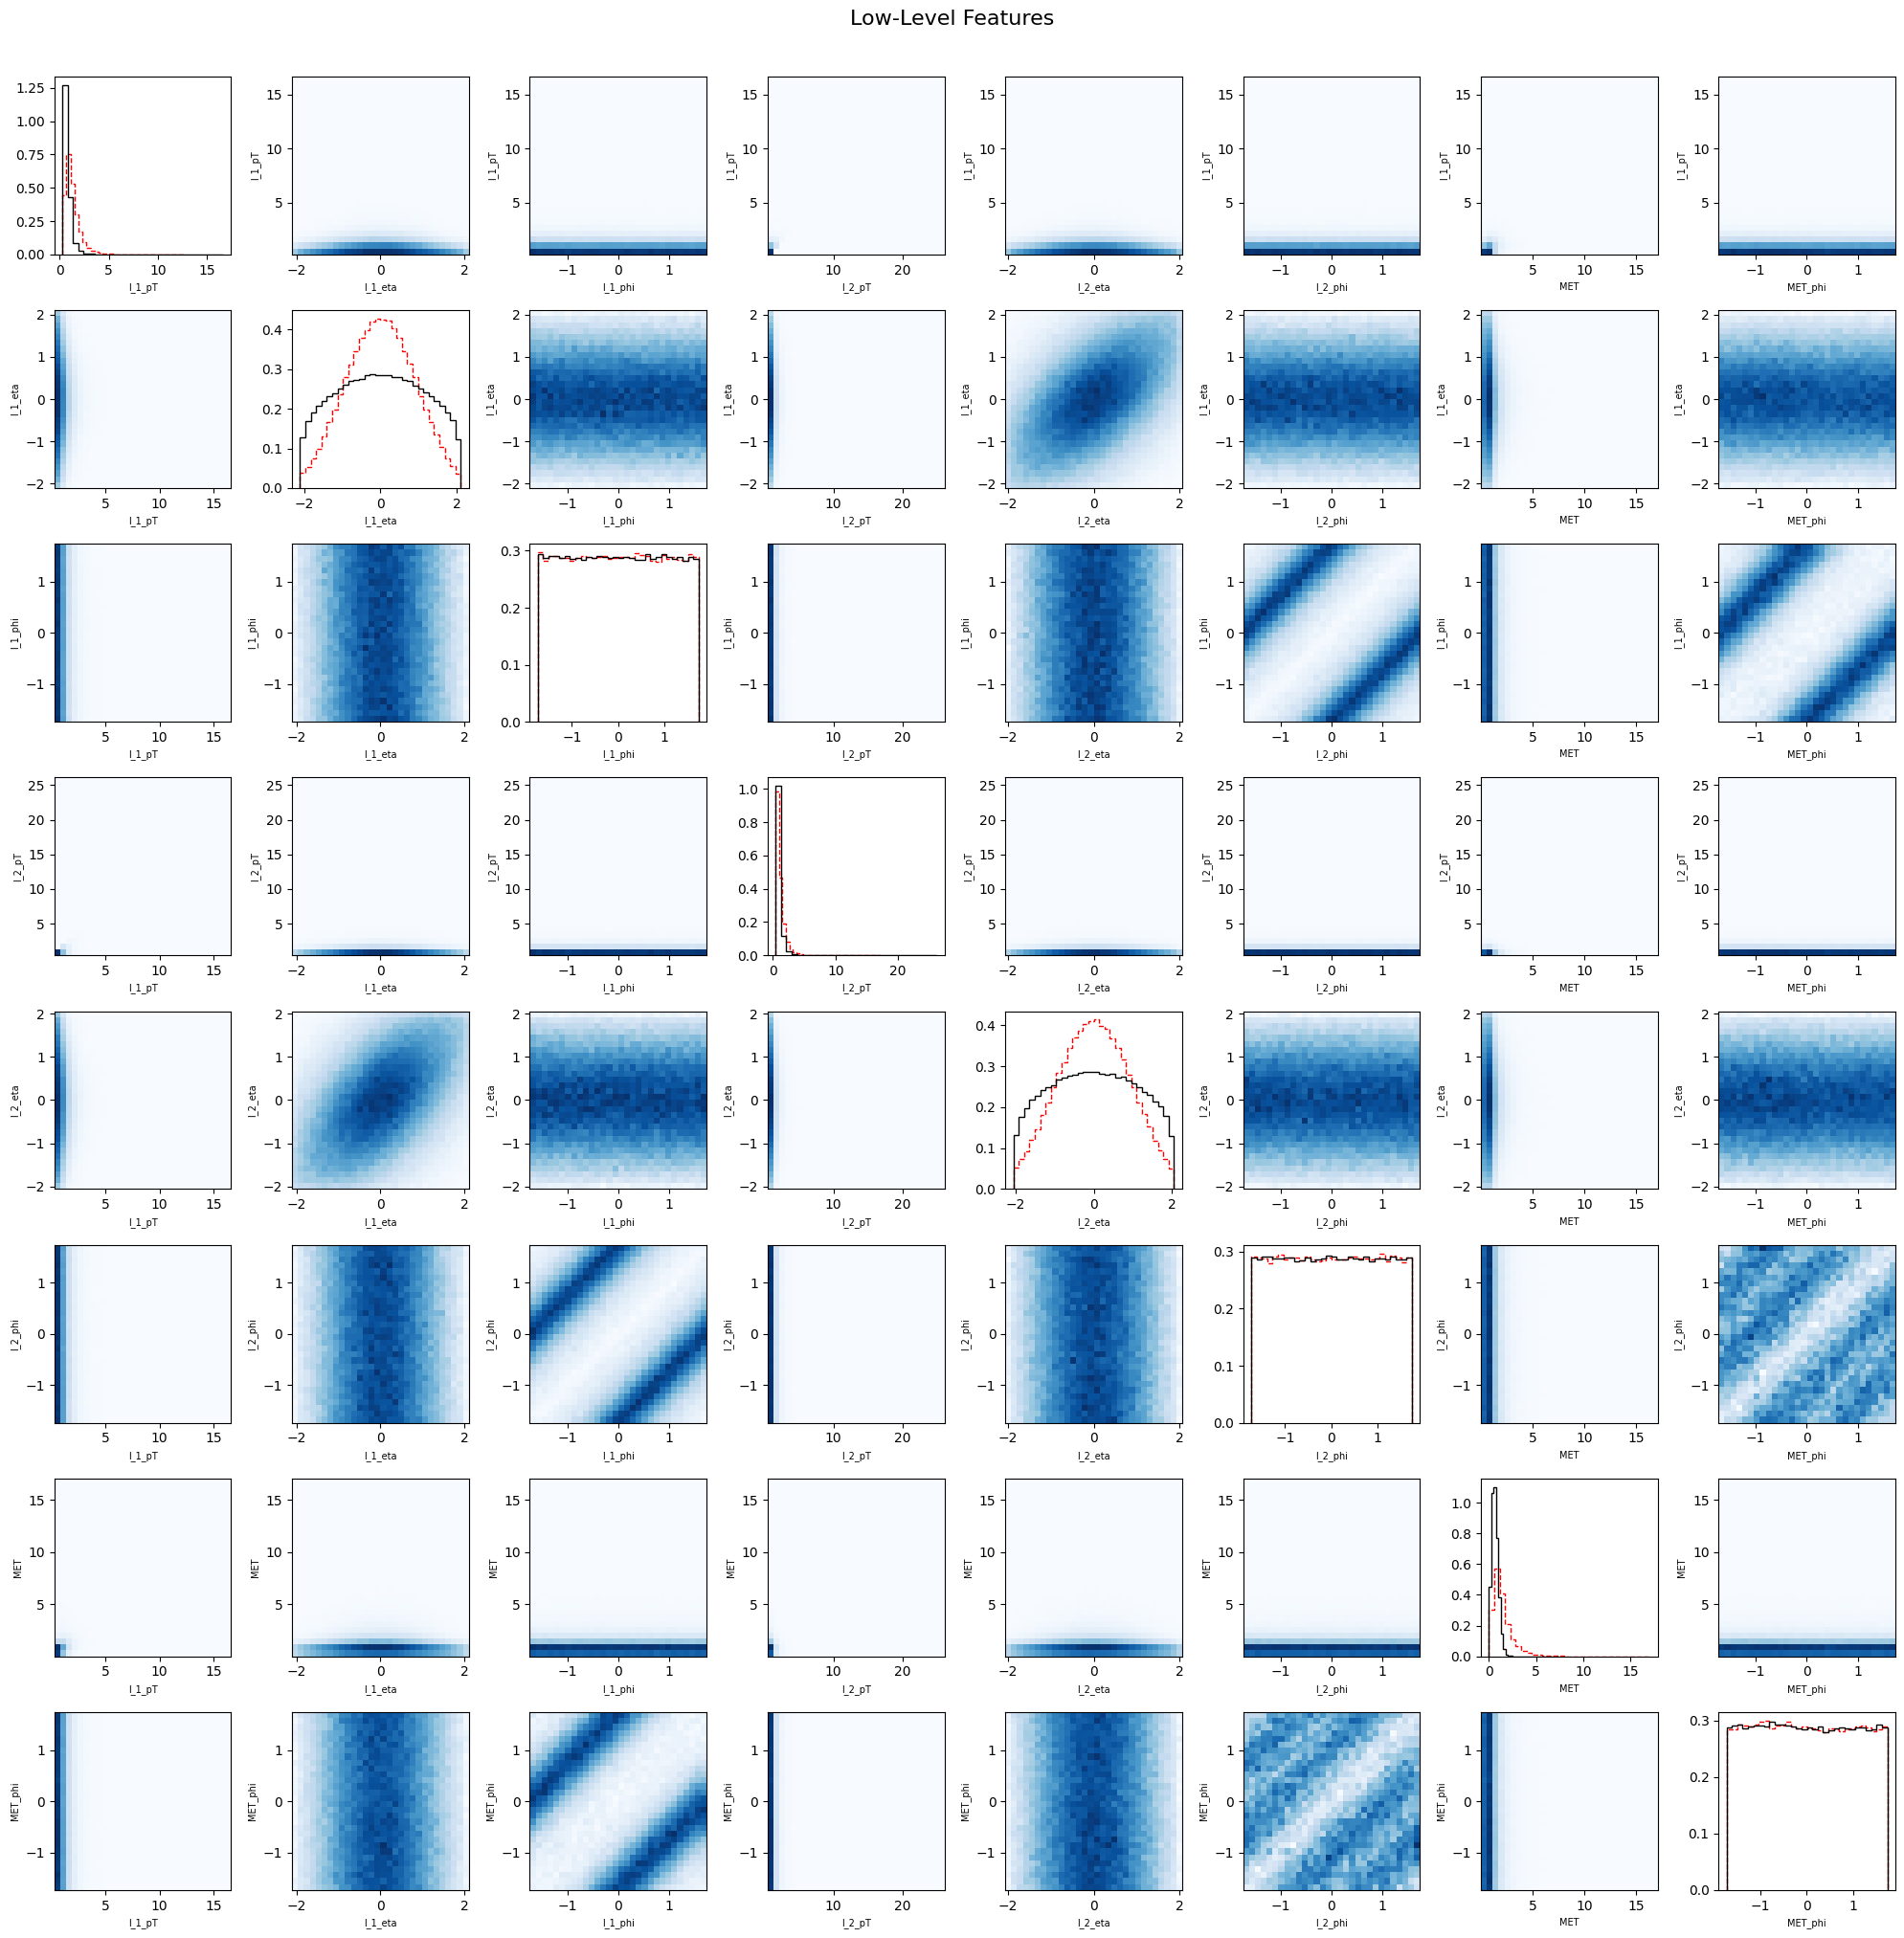

In [23]:
# For RawNames
pair_plot(df, RawNames, title="Low-Level Features")

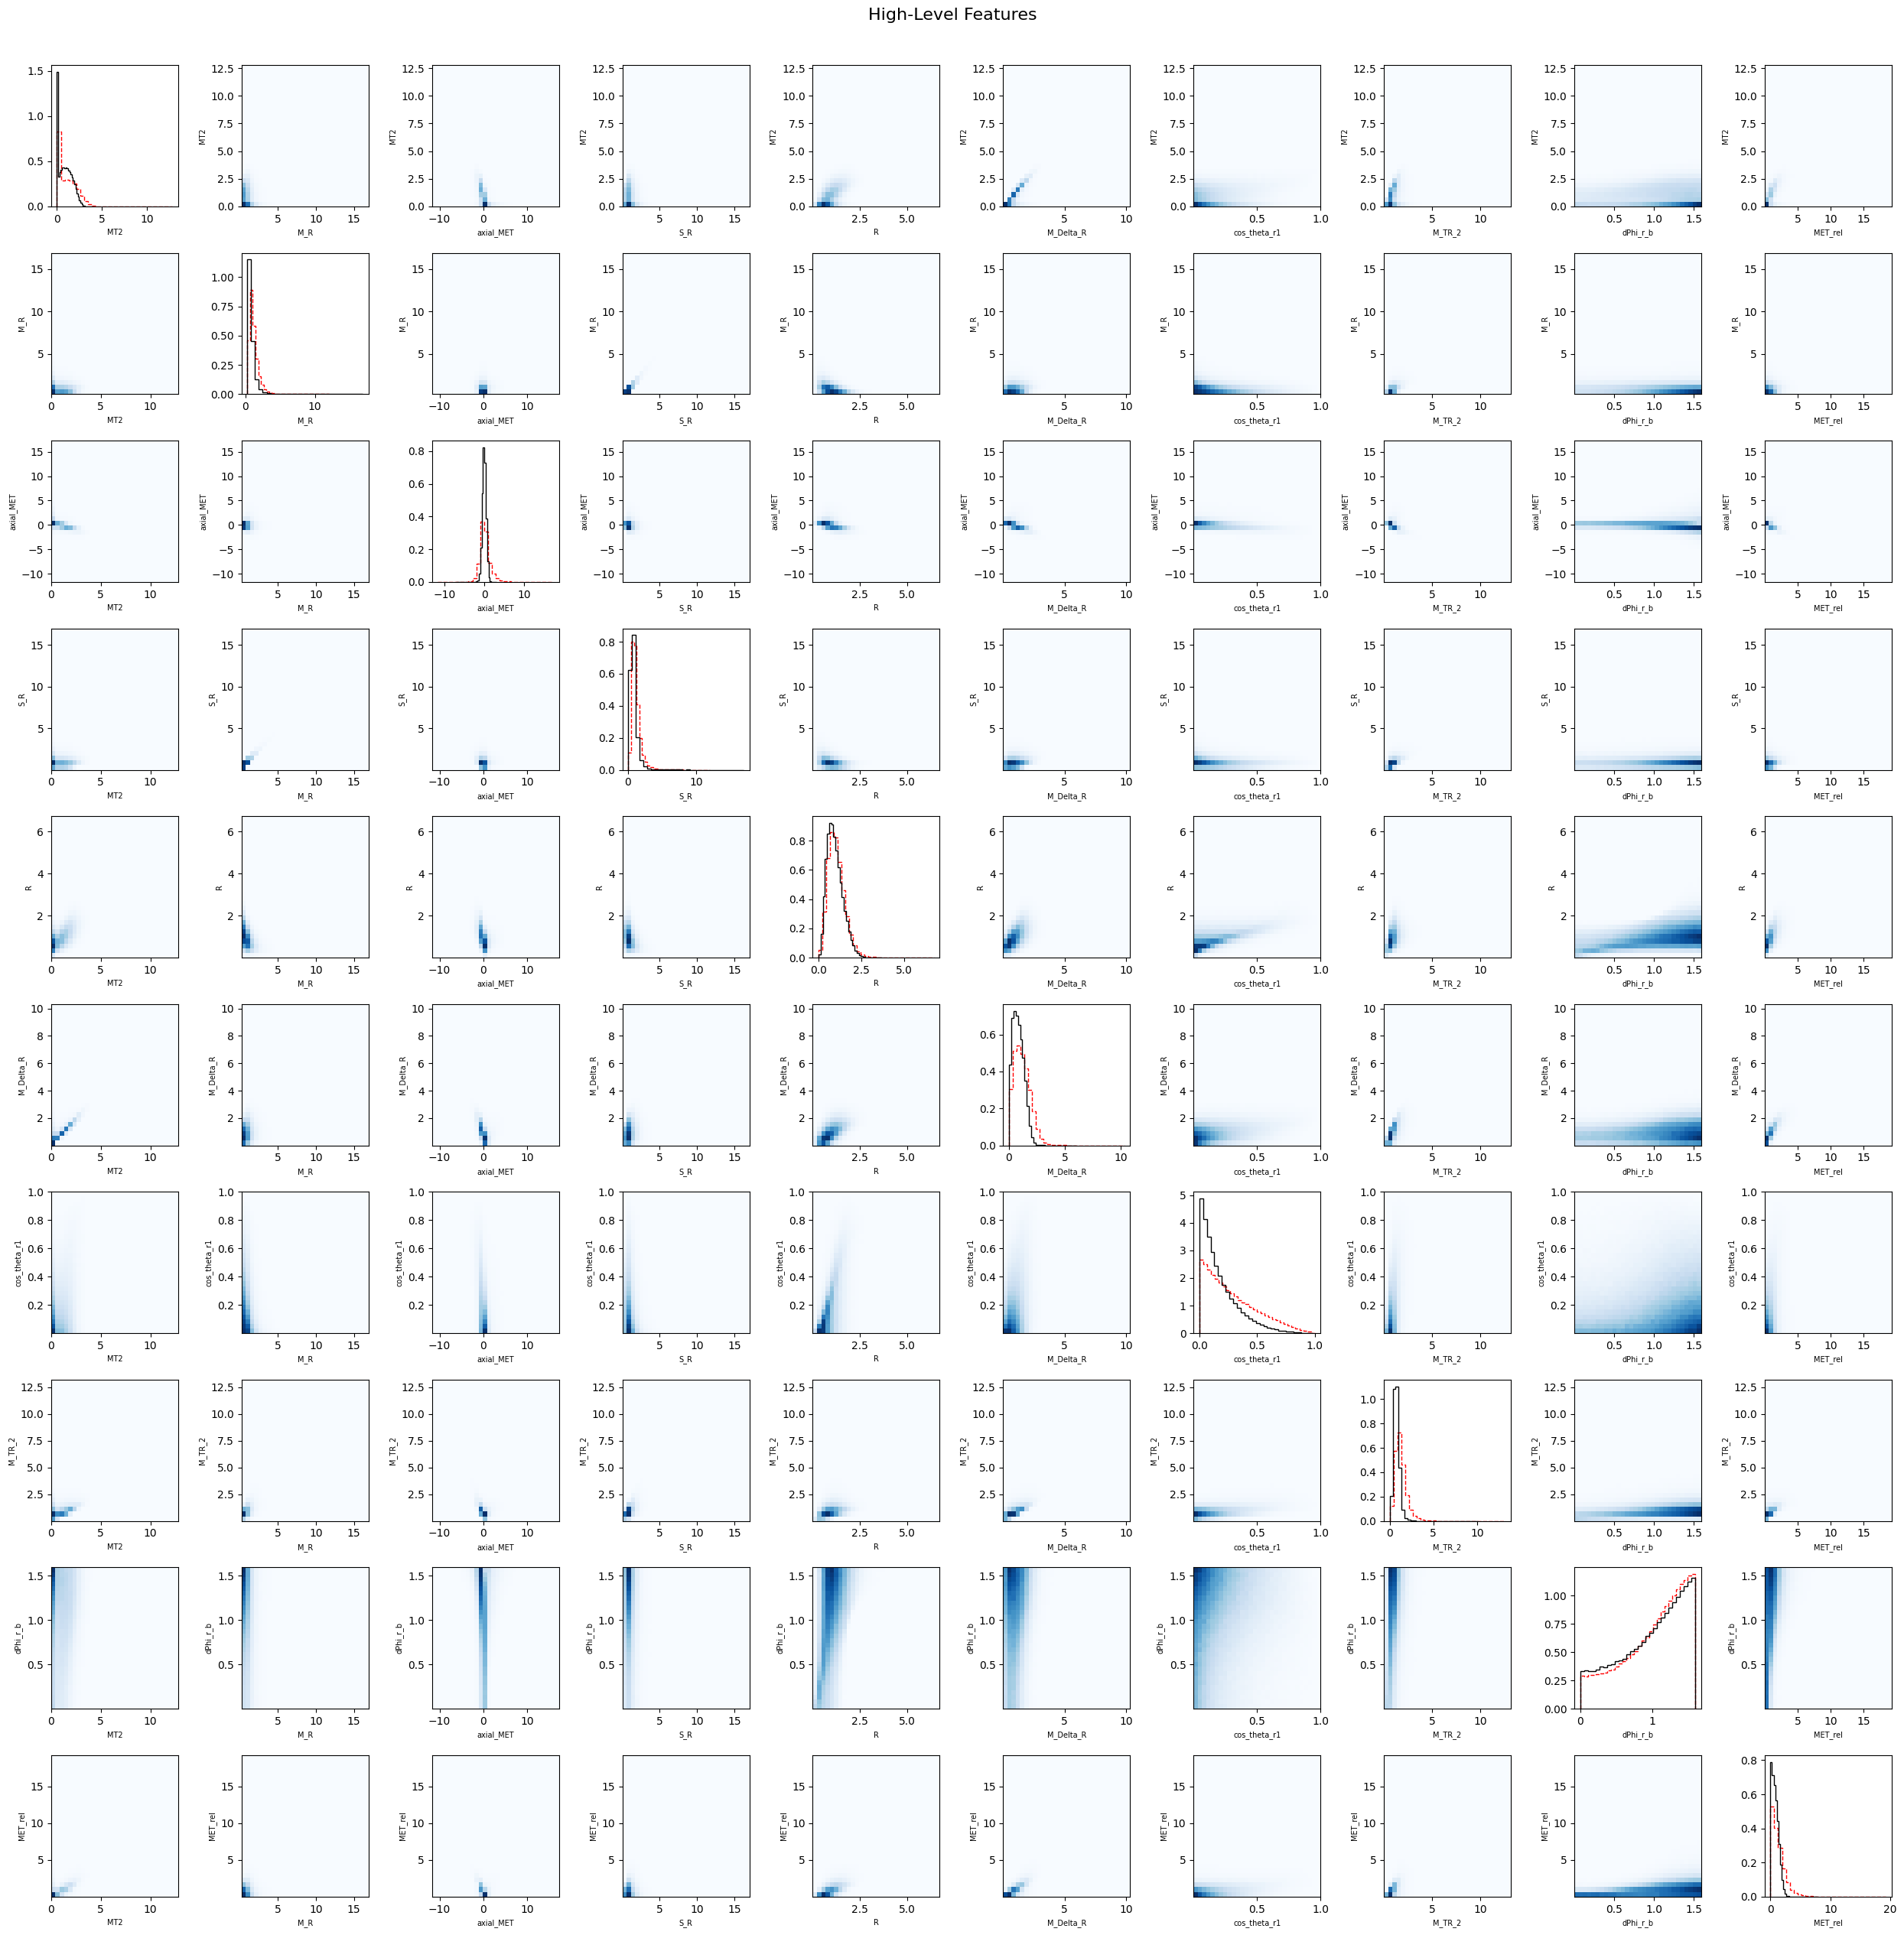

In [24]:
#For Feature Name:
pair_plot(df, FeatureNames, title="High-Level Features")

In [25]:
# Part b

#Create a function that creates a plot grid where
#1. diagonal cells show normalized 1D histogram for both singal avd background
#2. Other than diagonal cells show 2D heatmaps of the combined dataset for each variable pair

def pair_plot_fast(df, varnames, title="pair Plot"):    #Takes dataframe, list of column_names, and plot title as argument
    n=len(varnames)
    
    #Creates a grid of subplots (n rows and n columns), each of size 2.5*2.5 
    fig, axes = plt.subplots(n, n, figsize=(2.5 * n, 2.5 * n))
    
    #Provide the title for the plot with a font size of 14 units
    fig.suptitle(title, fontsize=16, y=1.01)    #y=1.01 sets the title slightly above its default value preventing the overlapping of plot and title
    
    
    #Pre extract each variabl's value as NumPy arrays for all 3 dataset. 
    #This will help avoid the use of nested iteration, making the performance faster.
    sig_arrays= {v: df_sig[v].to_numpy() for v in varnames}   #Numpy array for signal dataset
    bkg_arrays= {v: df_bkg[v].to_numpy() for v in varnames}   #Numpy array for backrgounds
    all_arrays= {v: df[v].to_numpy() for v in varnames}       #Numpy array for both background and signal

    
    #Iterates over every cell in nxn grid
    for i, var_y in enumerate(varnames):   #i selects y-axis variable (row)
        for j, var_x in enumerate(varnames):    #j selects x-axis variable (column)
            ax= axes[i][j]
            
            #For leading diagonal (i==j), shows 1D density histogram to compare signal and background for corresponding variable
            if i==j:
                s_counts, s_edges= np.histogram(sig_arrays[var_x], bins=30, density=True)
                b_counts, b_edges= np.histogram(bkg_arrays[var_x], bins=30, density=True)
                
                #Draws step histograms where dashed red is for signal and solid black is for background.
                #s_edges[:-1] uses the left edge of each bin as the x position
                ax.step(s_edges[:-1], s_counts, color='red', linestyle='dashed', label='signal')
                ax.step(b_edges[:-1], b_counts, color='black', label='Bkg')
                ax.set_xlabel(var_x, fontsize=7)
            
            #Else, computer a 2D histrogram (n_x_bins, n_y_bins)
            else:
                h, xedges, yedges = np.histogram2d(all_arrays[var_x], all_arrays[var_y], bins=30)
                
                # Plot histogram as colored grid
                ax.pcolormesh(xedges, yedges, h.T, cmap="Blues")    # h.T so rows match y-axis
                ax.set_xlabel(var_x, fontsize=7)
                ax.set_ylabel(var_y, fontsize=7)
    plt.tight_layout()
    plt.show()

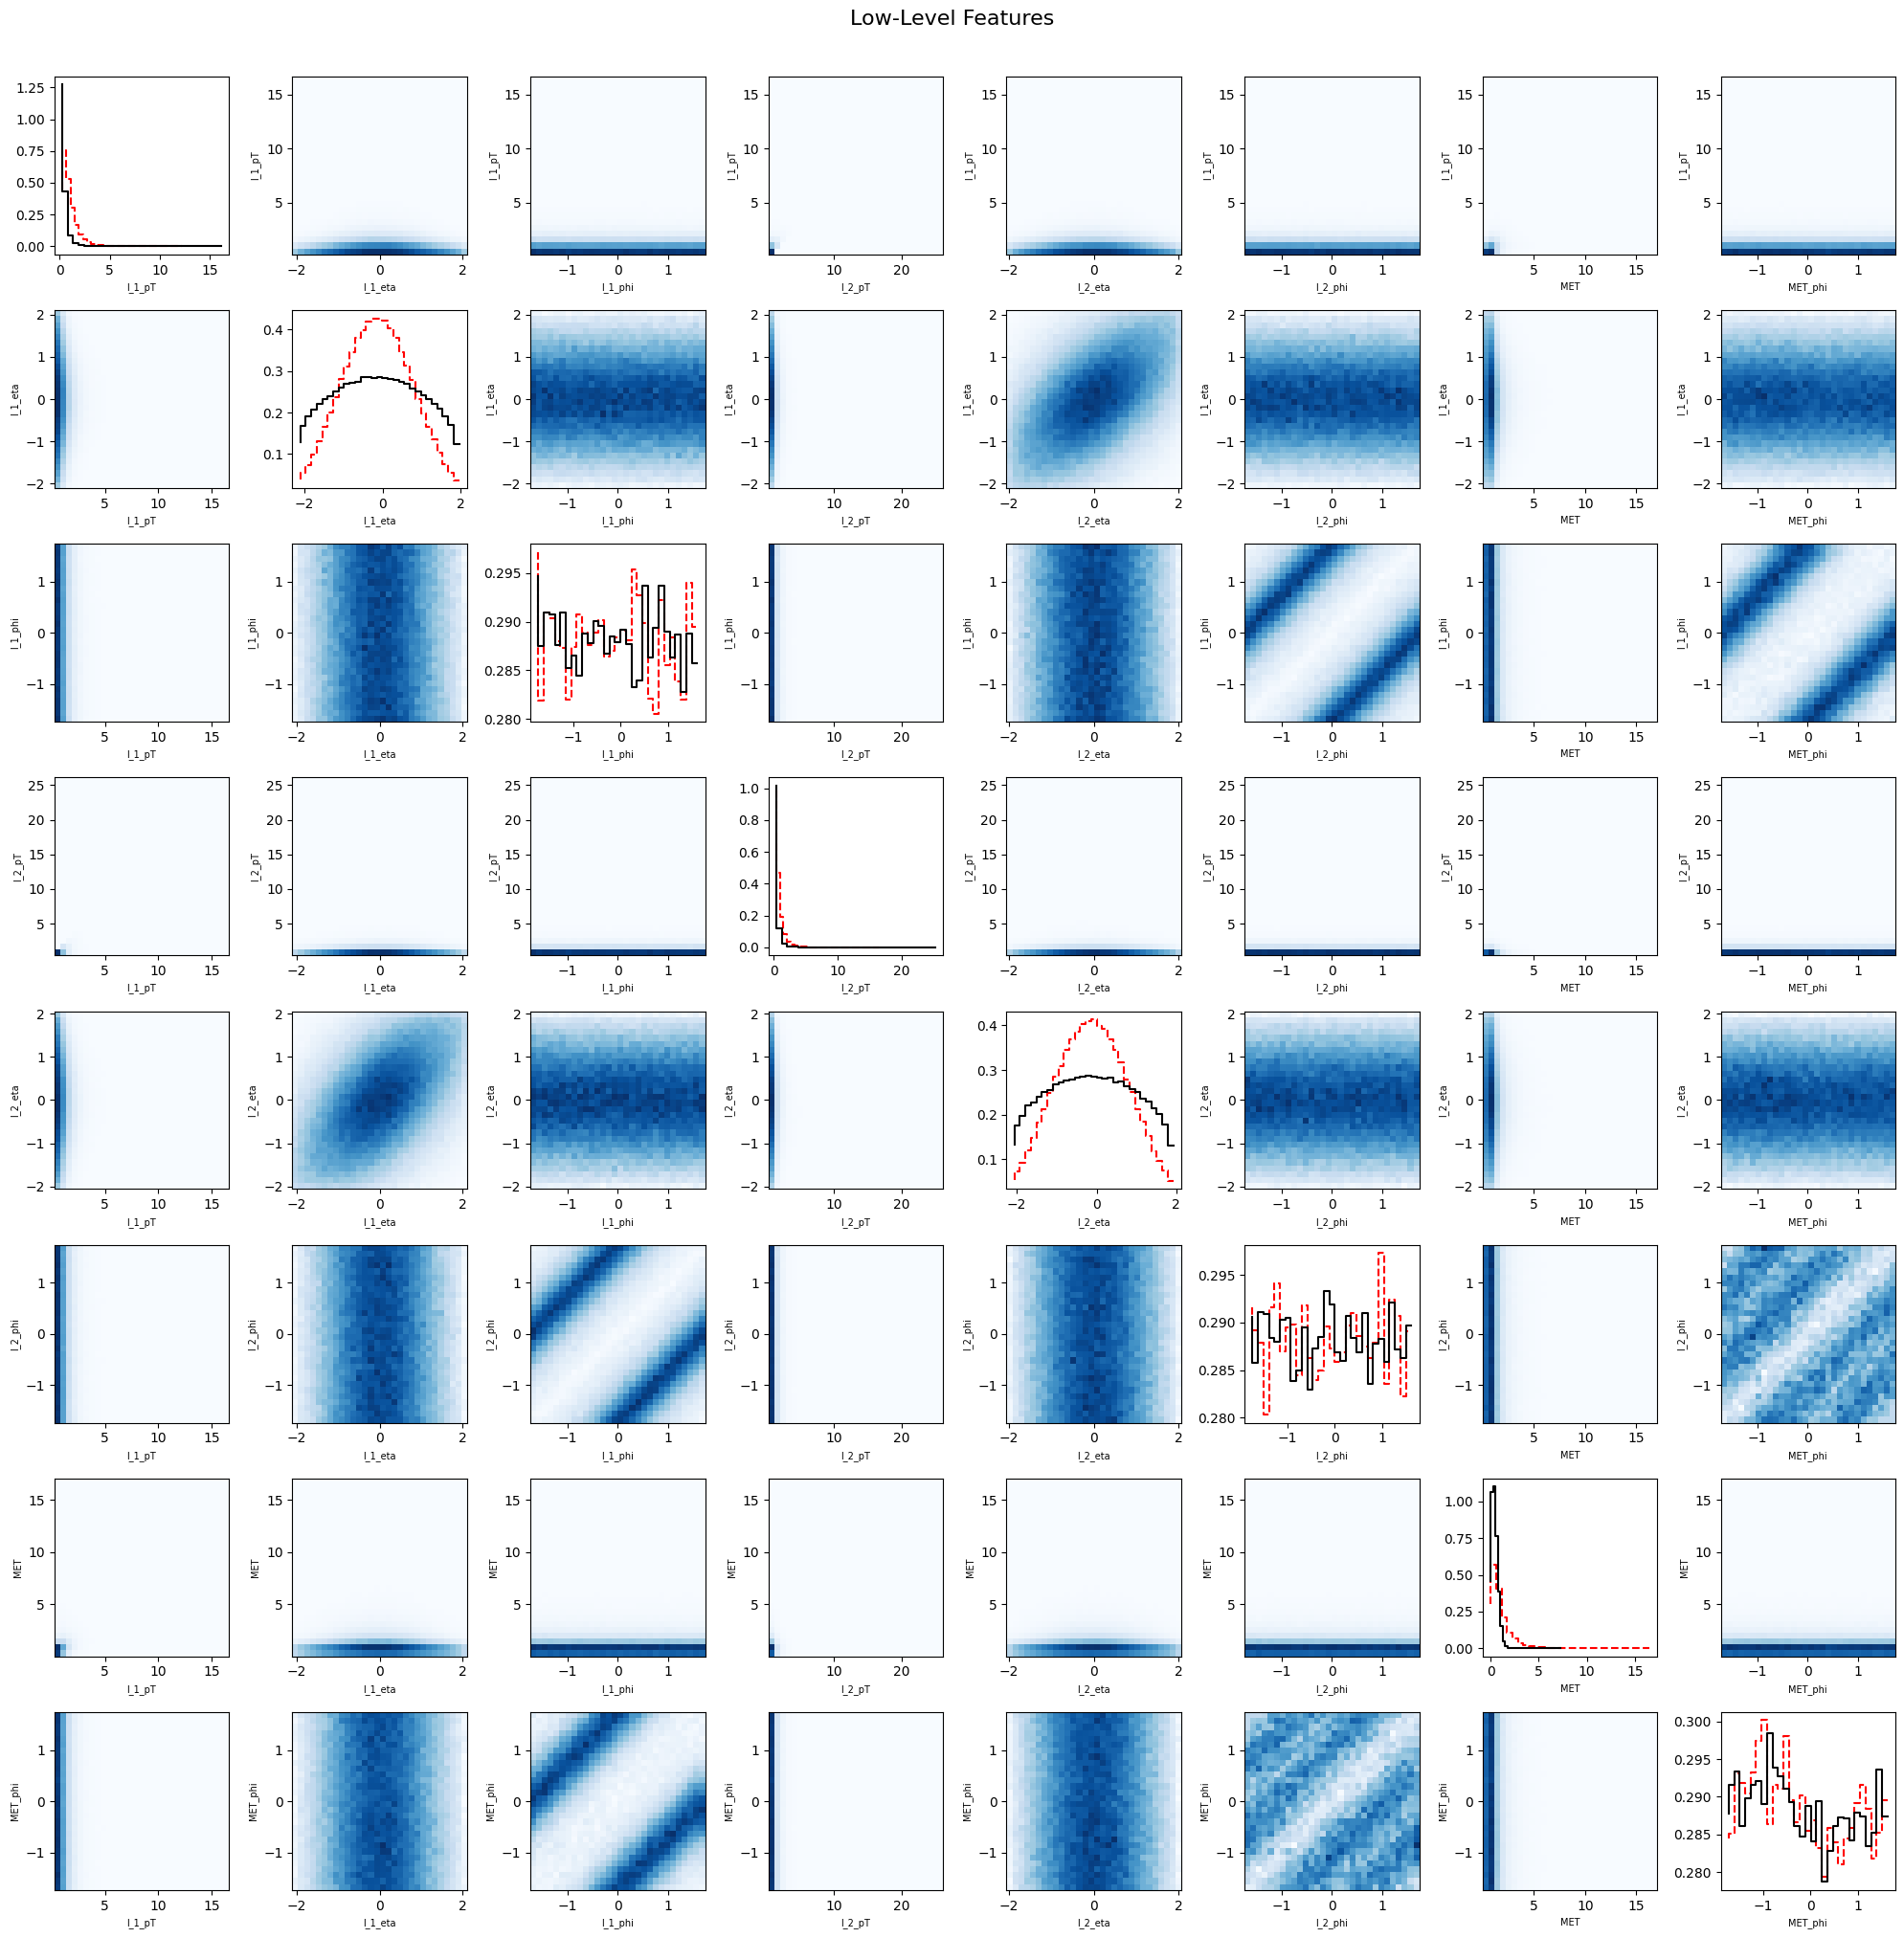

In [26]:
pair_plot_fast(df, RawNames, title="Low-Level Features")

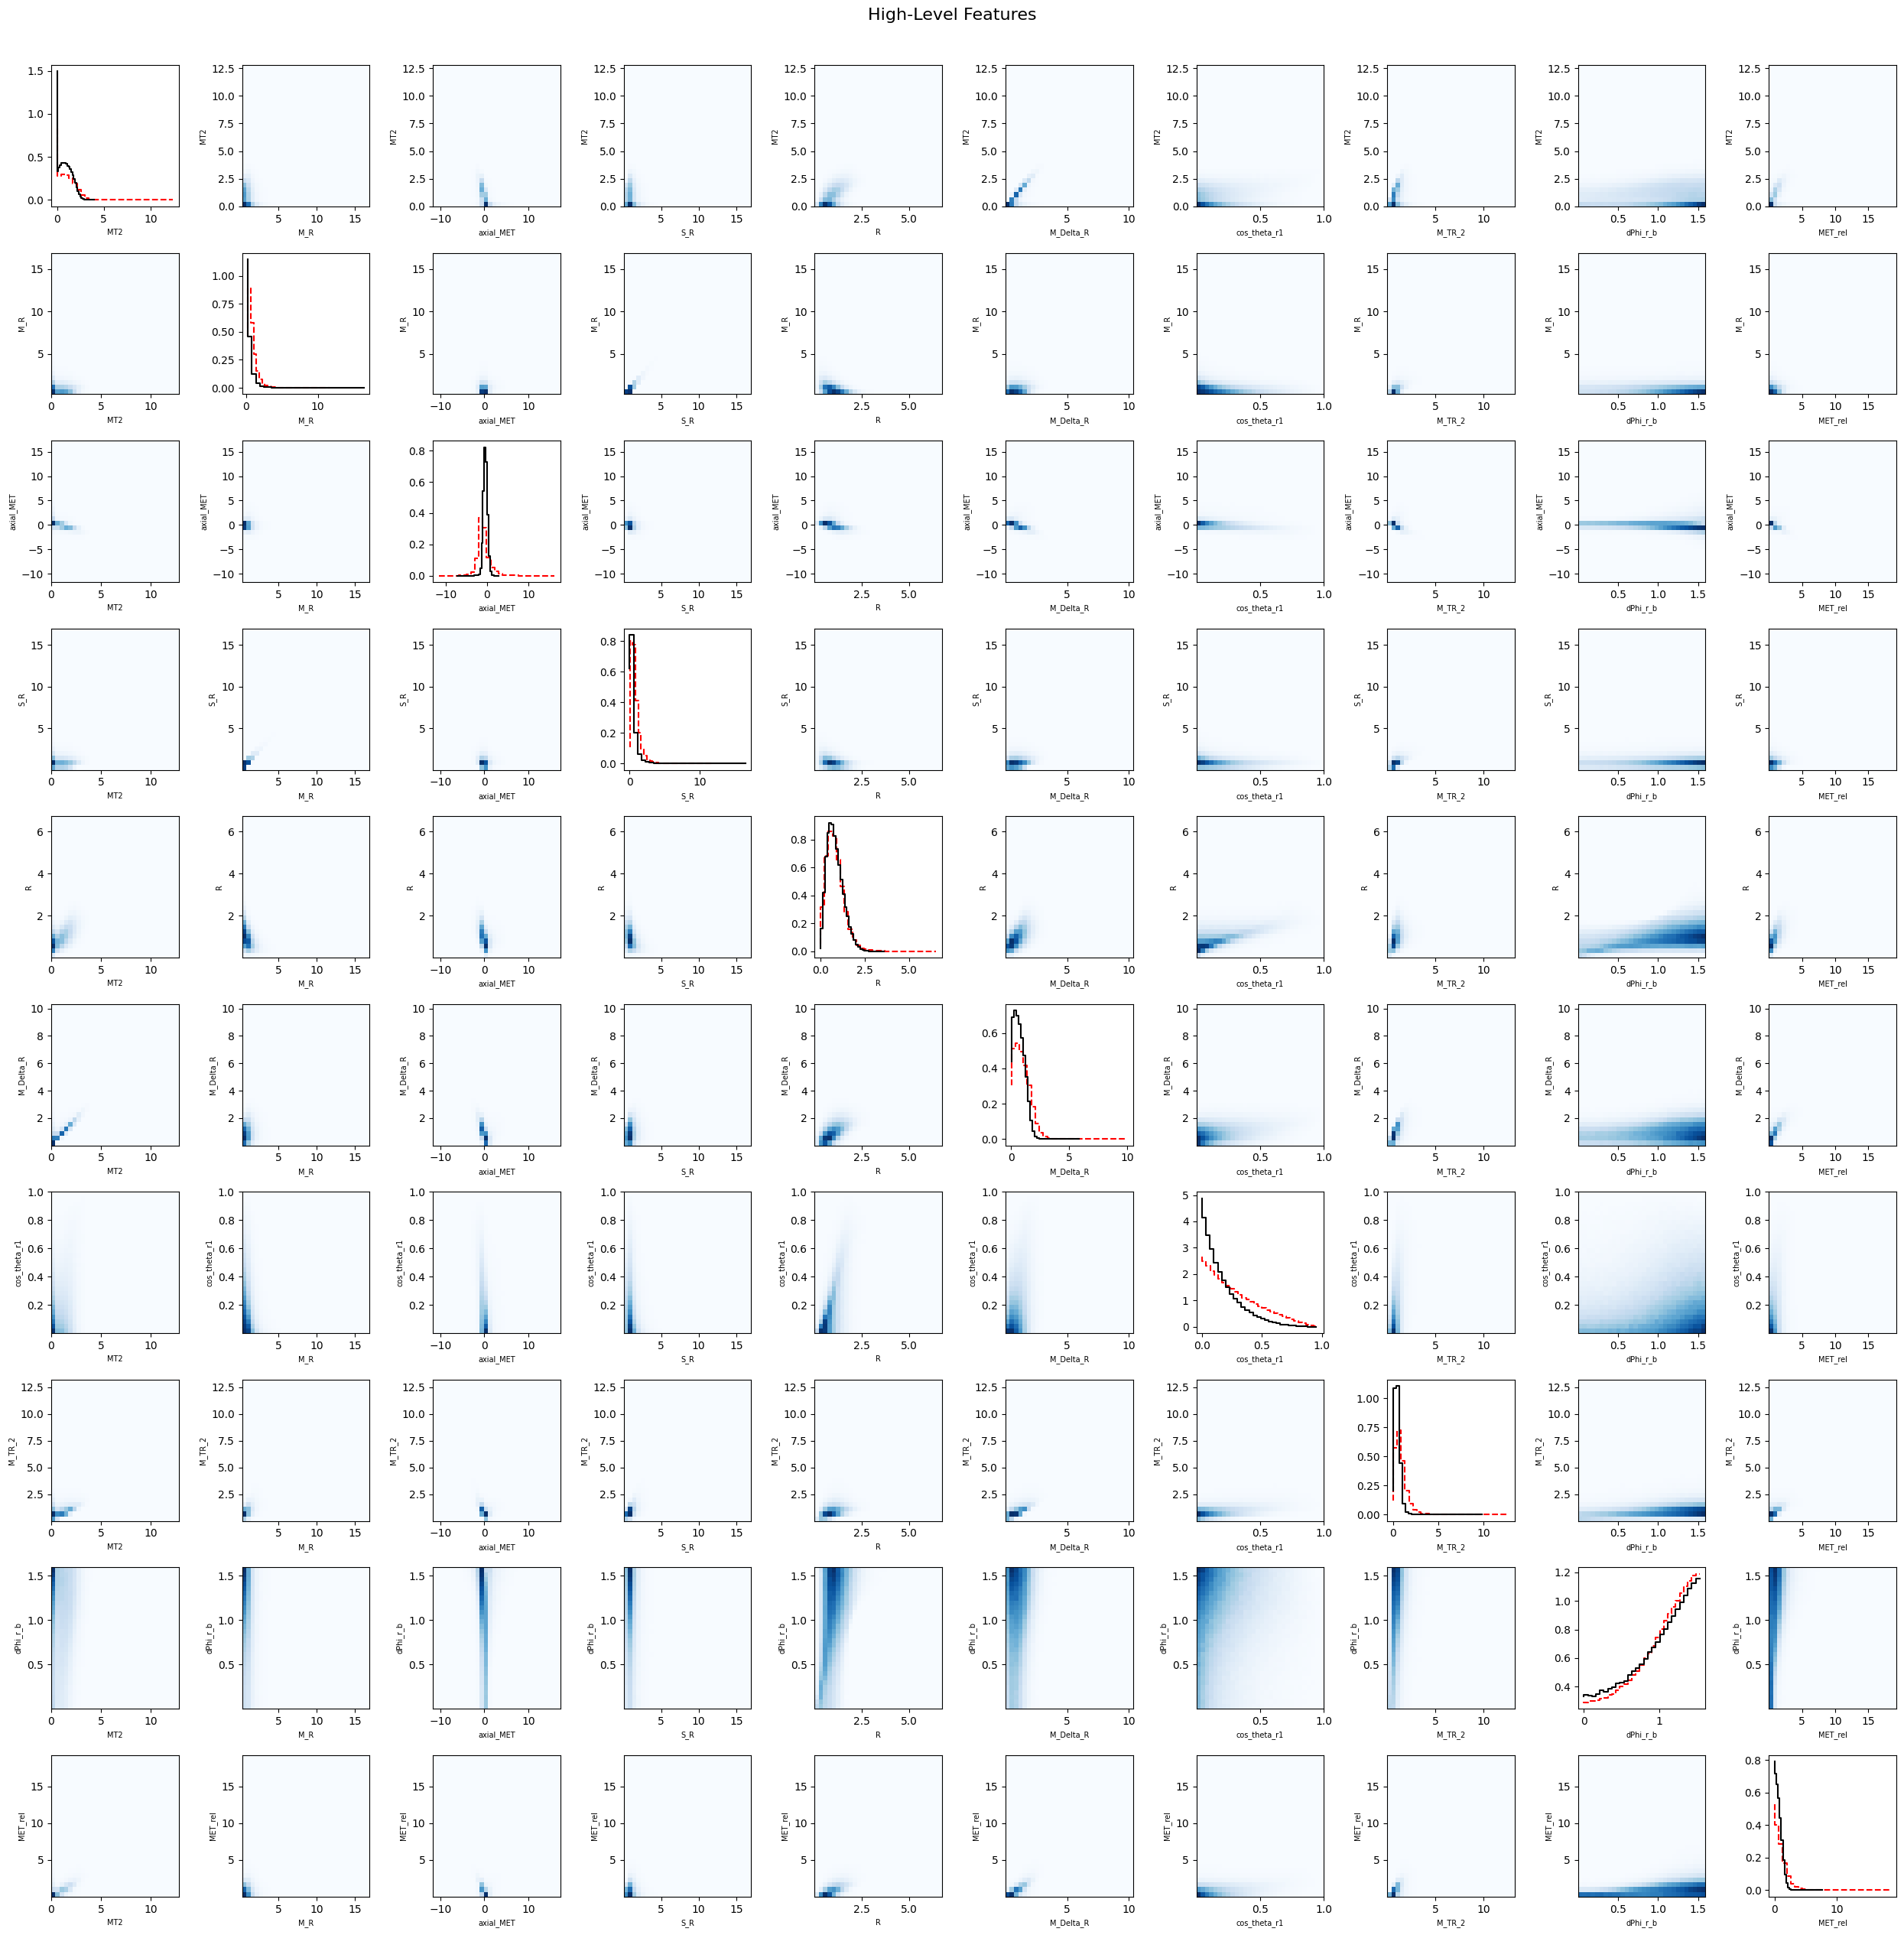

In [27]:
pair_plot_fast(df, FeatureNames, title="High-Level Features")

## Conclusion
### Low-level Features
- **l_1_pT** and **l_2_pT** show the best separation among low-level features. signal (red dashed) peaks sharply at low pT while background (black) has a heavier tail.
- **MET** also shows some separation, with signal decaying faster than background.
- **l_1_eta**, **l_2_phi**, and **MET_phi** show virtually **no separation**- both distributions are essentially flat and identical, making them poor discriminators.

### High-Level Features
- **cos_theta_r1** It shows strong separation, i.e. signals are more uniformly distributes while backhround peaks toward 0.
- **M_Dental_R** shoes clear seperation with signal peaking at lower values.
- **M_TR_2** shows good separation, with background dropping off fatser than signal.
- **R** and **dPhi_r_b** show mild separations
- **axial_MET** shows the least separation among high-level features. Their distributions are nearlu identical and centered near 0.
- **S_R**, **MER_rel**, **MT2**, and **M_R__ are mostly overlapping with only modest differences.

### Conclusion
High-level features generally provide **better signal/background separation** than low-level features, particularly **cos_theta_r1** and **M_Delta_R**. AMong low-level features, **l_1_pT** and **l_2_pT** are the most useful discriminators. Angular variables (phi) carry almost **no discriminating power**. This is consistent with the original paper's motivation for using engineered high-level features- they encode physics knowledge that raw kinematics alone do not capture efficiently.

### Exercise 4.2

#### Part a
Install [tabulate](https://github.com/astanin/python-tabulate). 

#### Part b
Use numpy to compute the [covariance matrix](https://numpy.org/doc/stable/reference/generated/numpy.cov.html) and [correlation matrix](https://numpy.org/doc/stable/reference/generated/numpy.corrcoef.html) between all observabes, and separately between low and high-level features.

#### Part c
Use tabulate to create a well formatted table of the covariance and correlation matrices, with nice headings and appropriate significant figures. Embed the table into this notebook.

#### Part d
Write a function that takes a dataset and appropriate arguments and performs steps b and c.  

In [28]:
%pip install Ipython tabulate

Note: you may need to restart the kernel to use updated packages.


Hint: Example code for embedding a `tabulate` table into a notebook:

In [29]:
import tabulate
from IPython.display import HTML, display

In [30]:
from IPython.display import HTML, display
import tabulate
table = [["A",1,2],
        ["C",3,4],
        ["D",5,6]]
display(HTML(tabulate.tabulate(table, tablefmt='html', headers=["X","Y","Z"])))

X,Y,Z
A,1,2
C,3,4
D,5,6


In [31]:
# Exercise 4.2 b
data_raw  = df[RawNames].to_numpy().T
data_feat = df[FeatureNames].to_numpy().T

# Low-level features
cov_raw  = np.cov(data_raw)
corr_raw = np.corrcoef(data_raw)

# High-level features
cov_feat  = np.cov(data_feat)
corr_feat = np.corrcoef(data_feat)
print(cov_feat)   #Test

[[ 0.73766054 -0.03654441 -0.46099861 -0.01103752  0.23210005  0.43289693
   0.04462891  0.18916951  0.02089723  0.40877889]
 [-0.03654441  0.39216708  0.01713455  0.37976344 -0.11290414  0.07393003
  -0.01434118  0.20987467 -0.02896168  0.04368455]
 [-0.46099861  0.01713455  1.00537396 -0.04138282 -0.18090014 -0.23307398
  -0.05373485 -0.18501679 -0.02511279 -0.1198512 ]
 [-0.01103752  0.37976344 -0.04138282  0.38201461 -0.08335872  0.0957808
  -0.0103629   0.2281247  -0.00345651  0.08231538]
 [ 0.23210005 -0.11290414 -0.18090014 -0.08335872  0.22157807  0.16548304
   0.05816081  0.10401425  0.08709136  0.24882357]
 [ 0.43289693  0.07393003 -0.23307398  0.0957808   0.16548304  0.38862381
   0.03920886  0.24186516  0.04224066  0.41474304]
 [ 0.04462891 -0.01434118 -0.05373485 -0.0103629   0.05816081  0.03920886
   0.0388299   0.05166586  0.00908347  0.05531787]
 [ 0.18916951  0.20987467 -0.18501679  0.2281247   0.10401425  0.24186516
   0.05166586  0.33782719  0.05813297  0.30199264]
 

In [32]:
# Exercise 4.2 c

# Low-Level Features
headers = [""] + RawNames    #Firsr column is blank (for row labels), rest are variable names

rows = []    #Empty list
for i, row in enumerate(cov_raw):    #Loops over index and row of the matrix
    rows.append([RawNames[i]] + [f"{val:.3f}" for val in row])    #Adds list of variable name with values round to 3 decimal place
print(f"\n\nCovariance Matrix: Low-Level Features")
display(HTML(tabulate.tabulate(rows, tablefmt='html', headers=headers)))    #Displays the rows in HTML table format

rows = []    #Empty list
for i, row in enumerate(corr_raw):    #Loops over index and row of the matrix
    rows.append([RawNames[i]] + [f"{val:.3f}" for val in row])    #Adds list of variable name with values round to 3 decimal place
print(f"Correlation Matrix: Low-Level Features")
display(HTML(tabulate.tabulate(rows, tablefmt='html', headers=headers)))    #Displays the rows in HTML table format

# High-Level Features
headers = [""] + FeatureNames    #Firsr column is blank (for row labels), rest are variable names

rows = []    #Empty list
for i, row in enumerate(cov_feat):    #Loops over index and row of the matrix
    rows.append([FeatureNames[i]] + [f"{val:.3f}" for val in row])    #Adds list of variable name with values round to 3 decimal place
print(f"\n\nCovariance Matrix: High-Level Features")
display(HTML(tabulate.tabulate(rows, tablefmt='html', headers=headers)))    #Displays the rows in HTML table format

rows = []    #Empty list
for i, row in enumerate(corr_feat):    #Loops over index and row of the matrix
    rows.append([FeatureNames[i]] + [f"{val:.3f}" for val in row])    #Adds list of variable name with values round to 3 decimal place
print(f"Correlation Matrix: High-Level Features")
display(HTML(tabulate.tabulate(rows, tablefmt='html', headers=headers)))    #Displays the rows in HTML table format



Covariance Matrix: Low-Level Features


,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi
l_1_pT,0.467,-0,0,0.305,-0,0.001,0.228,-0.001
l_1_eta,-0,1.004,-0.001,-0,0.408,-0.001,-0.002,-0.001
l_1_phi,0,-0.001,1.004,0.001,0,-0.267,0.001,-0.185
l_2_pT,0.305,-0,0.001,0.425,-0.001,0,0.079,-0.002
l_2_eta,-0,0.408,0,-0.001,1.006,0,0,-0
l_2_phi,0.001,-0.001,-0.267,0,0,1.004,-0,-0.035
MET,0.228,-0.002,0.001,0.079,0,-0,0.762,-0.003
MET_phi,-0.001,-0.001,-0.185,-0.002,-0,-0.035,-0.003,1.003


Correlation Matrix: Low-Level Features


,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi
l_1_pT,1,-0.001,0,0.684,-0.001,0.001,0.383,-0.001
l_1_eta,-0.001,1,-0.001,-0,0.406,-0.001,-0.002,-0.001
l_1_phi,0,-0.001,1,0.002,0,-0.266,0.001,-0.184
l_2_pT,0.684,-0,0.002,1,-0.001,0,0.14,-0.002
l_2_eta,-0.001,0.406,0,-0.001,1,0,0,-0
l_2_phi,0.001,-0.001,-0.266,0,0,1,-0,-0.035
MET,0.383,-0.002,0.001,0.14,0,-0,1,-0.003
MET_phi,-0.001,-0.001,-0.184,-0.002,-0,-0.035,-0.003,1




Covariance Matrix: High-Level Features


,MT2,M_R,axial_MET,S_R,R,M_Delta_R,cos_theta_r1,M_TR_2,dPhi_r_b,MET_rel
MT2,0.738,-0.037,-0.461,-0.011,0.232,0.433,0.045,0.189,0.021,0.409
M_R,-0.037,0.392,0.017,0.38,-0.113,0.074,-0.014,0.21,-0.029,0.044
axial_MET,-0.461,0.017,1.005,-0.041,-0.181,-0.233,-0.054,-0.185,-0.025,-0.12
S_R,-0.011,0.38,-0.041,0.382,-0.083,0.096,-0.01,0.228,-0.003,0.082
R,0.232,-0.113,-0.181,-0.083,0.222,0.165,0.058,0.104,0.087,0.249
M_Delta_R,0.433,0.074,-0.233,0.096,0.165,0.389,0.039,0.242,0.042,0.415
cos_theta_r1,0.045,-0.014,-0.054,-0.01,0.058,0.039,0.039,0.052,0.009,0.055
M_TR_2,0.189,0.21,-0.185,0.228,0.104,0.242,0.052,0.338,0.058,0.302
dPhi_r_b,0.021,-0.029,-0.025,-0.003,0.087,0.042,0.009,0.058,0.19,0.146
MET_rel,0.409,0.044,-0.12,0.082,0.249,0.415,0.055,0.302,0.146,0.79


Correlation Matrix: High-Level Features


,MT2,M_R,axial_MET,S_R,R,M_Delta_R,cos_theta_r1,M_TR_2,dPhi_r_b,MET_rel
MT2,1,-0.068,-0.535,-0.021,0.574,0.809,0.264,0.379,0.056,0.535
M_R,-0.068,1,0.027,0.981,-0.383,0.189,-0.116,0.577,-0.106,0.078
axial_MET,-0.535,0.027,1,-0.067,-0.383,-0.373,-0.272,-0.317,-0.057,-0.134
S_R,-0.021,0.981,-0.067,1,-0.287,0.249,-0.085,0.635,-0.013,0.15
R,0.574,-0.383,-0.383,-0.287,1,0.564,0.627,0.38,0.424,0.595
M_Delta_R,0.809,0.189,-0.373,0.249,0.564,1,0.319,0.668,0.155,0.748
cos_theta_r1,0.264,-0.116,-0.272,-0.085,0.627,0.319,1,0.451,0.106,0.316
M_TR_2,0.379,0.577,-0.317,0.635,0.38,0.668,0.451,1,0.229,0.584
dPhi_r_b,0.056,-0.106,-0.057,-0.013,0.424,0.155,0.106,0.229,1,0.378
MET_rel,0.535,0.078,-0.134,0.15,0.595,0.748,0.316,0.584,0.378,1


In [33]:
def compute_and_display_matrices(df, varnames, label="Features"):
    
    # Extract selected columns as NumPy array, transposed so each row = one variable
    data= df[varnames].to_numpy().T
    
    #Compute covariance and correlation matrices
    cov_matrix= np.cov(data)
    corr_matrix= np.corrcoef(data)
    
    #Converts a matrix into a list of row with variable name+rounded values and returns it
    def matrix_to_table(matrix, varnames):
        rows=[]    #Empty list
        for i, row in enumerate(matrix):    #Loops over index and row of the matrix
            rows.append([varnames[i]]+ [f"{val:.3f}" for val in row])   #Adds list of variable name with values round to 3 decimal place.
        return rows
    
    
    #Firsr column is blank (for row labels), rest are variable names
    headers= [""]+ varnames

    
    #Dsiplay covariance matrix in HTML table form
    print(f"\n\nCorrelation Matrix: {label}")
    cov_table= matrix_to_table(cov_matrix, varnames)    #Calls the above function
    display(HTML(tabulate.tabulate(cov_table, tablefmt='html', headers=headers)))    #Displays the cov_table in HTML table format

    #Dsiplay correlation matrix in HTML table form
    print(f"Correlation Matrix: {label}")
    corr_table= matrix_to_table(corr_matrix, varnames)
    display(HTML(tabulate.tabulate(corr_table, tablefmt='html', headers= headers)))

    return cov_matrix, corr_matrix    #return covariance and correlation matrix


# Low-Level Only
cov_raw,  corr_raw  = compute_and_display_matrices(df, RawNames,     label="Low-Level Features")

# High-level only
cov_feat, corr_feat = compute_and_display_matrices(df, FeatureNames, label="High-Level Features")



Correlation Matrix: Low-Level Features


,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi
l_1_pT,0.467,-0,0,0.305,-0,0.001,0.228,-0.001
l_1_eta,-0,1.004,-0.001,-0,0.408,-0.001,-0.002,-0.001
l_1_phi,0,-0.001,1.004,0.001,0,-0.267,0.001,-0.185
l_2_pT,0.305,-0,0.001,0.425,-0.001,0,0.079,-0.002
l_2_eta,-0,0.408,0,-0.001,1.006,0,0,-0
l_2_phi,0.001,-0.001,-0.267,0,0,1.004,-0,-0.035
MET,0.228,-0.002,0.001,0.079,0,-0,0.762,-0.003
MET_phi,-0.001,-0.001,-0.185,-0.002,-0,-0.035,-0.003,1.003


Correlation Matrix: Low-Level Features


,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi
l_1_pT,1,-0.001,0,0.684,-0.001,0.001,0.383,-0.001
l_1_eta,-0.001,1,-0.001,-0,0.406,-0.001,-0.002,-0.001
l_1_phi,0,-0.001,1,0.002,0,-0.266,0.001,-0.184
l_2_pT,0.684,-0,0.002,1,-0.001,0,0.14,-0.002
l_2_eta,-0.001,0.406,0,-0.001,1,0,0,-0
l_2_phi,0.001,-0.001,-0.266,0,0,1,-0,-0.035
MET,0.383,-0.002,0.001,0.14,0,-0,1,-0.003
MET_phi,-0.001,-0.001,-0.184,-0.002,-0,-0.035,-0.003,1




Correlation Matrix: High-Level Features


,MT2,M_R,axial_MET,S_R,R,M_Delta_R,cos_theta_r1,M_TR_2,dPhi_r_b,MET_rel
MT2,0.738,-0.037,-0.461,-0.011,0.232,0.433,0.045,0.189,0.021,0.409
M_R,-0.037,0.392,0.017,0.38,-0.113,0.074,-0.014,0.21,-0.029,0.044
axial_MET,-0.461,0.017,1.005,-0.041,-0.181,-0.233,-0.054,-0.185,-0.025,-0.12
S_R,-0.011,0.38,-0.041,0.382,-0.083,0.096,-0.01,0.228,-0.003,0.082
R,0.232,-0.113,-0.181,-0.083,0.222,0.165,0.058,0.104,0.087,0.249
M_Delta_R,0.433,0.074,-0.233,0.096,0.165,0.389,0.039,0.242,0.042,0.415
cos_theta_r1,0.045,-0.014,-0.054,-0.01,0.058,0.039,0.039,0.052,0.009,0.055
M_TR_2,0.189,0.21,-0.185,0.228,0.104,0.242,0.052,0.338,0.058,0.302
dPhi_r_b,0.021,-0.029,-0.025,-0.003,0.087,0.042,0.009,0.058,0.19,0.146
MET_rel,0.409,0.044,-0.12,0.082,0.249,0.415,0.055,0.302,0.146,0.79


Correlation Matrix: High-Level Features


,MT2,M_R,axial_MET,S_R,R,M_Delta_R,cos_theta_r1,M_TR_2,dPhi_r_b,MET_rel
MT2,1,-0.068,-0.535,-0.021,0.574,0.809,0.264,0.379,0.056,0.535
M_R,-0.068,1,0.027,0.981,-0.383,0.189,-0.116,0.577,-0.106,0.078
axial_MET,-0.535,0.027,1,-0.067,-0.383,-0.373,-0.272,-0.317,-0.057,-0.134
S_R,-0.021,0.981,-0.067,1,-0.287,0.249,-0.085,0.635,-0.013,0.15
R,0.574,-0.383,-0.383,-0.287,1,0.564,0.627,0.38,0.424,0.595
M_Delta_R,0.809,0.189,-0.373,0.249,0.564,1,0.319,0.668,0.155,0.748
cos_theta_r1,0.264,-0.116,-0.272,-0.085,0.627,0.319,1,0.451,0.106,0.316
M_TR_2,0.379,0.577,-0.317,0.635,0.38,0.668,0.451,1,0.229,0.584
dPhi_r_b,0.056,-0.106,-0.057,-0.013,0.424,0.155,0.106,0.229,1,0.378
MET_rel,0.535,0.078,-0.134,0.15,0.595,0.748,0.316,0.584,0.378,1


## Exercise 5: Selection

### Exercise 5.1

Part a
By looking at the signal/background distributions for each observable (e.g. $x$) determine which selection criteria would be optimal: 

1. $x > x_c$
2. $x < x_c$
3. $|x - \mu| > x_c$
4. $|x - \mu| < x_c$

where $x_c$ is value to be determined below.

### Exercise 5.2

Plot the True Positive Rate (TPR) (aka signal efficiency $\epsilon_S(x_c)$) and False Positive Rate (FPR) (aka background efficiency $\epsilon_B(x_c)$) as function of $x_c$ for applying the strategy in part a to each observable. 

### Exercise 5.3
Assume 3 different scenarios corresponding to different numbers of signal and background events expected in data:

1. Expect $N_S=10$, $N_B=100$.
1. Expect $N_S=100$, $N_B=1000$.
1. Expect $N_S=1000$, $N_B=10000$.
1. Expect $N_S=10000$, $N_B=100000$.

Plot the significance ($\sigma_{S'}$) for each observable as function of $x_c$ for each scenario, where 

$\sigma_{S'}= \frac{N'_S}{\sqrt{N'_S+N'_B}}$

and $N'_{S,B} = \epsilon_{S,B}(x_c) * N_{S,B}$.

In [34]:
# Exercise 5.1

#Optimal selection criteria for each observable

selection_strategy = {
    "l_1_pT"      : "x > xc",
    "l_1_eta"     : "|x - mu| < xc",
    "l_1_phi"     : None,             # no separation
    "l_2_pT"      : "x > xc",
    "l_2_eta"     : "|x - mu| < xc",
    "l_2_phi"     : None,             # no separation
    "MET"         : "x > xc",
    "MET_phi"     : None,             # no separation
    "R"           : "x < xc",
    "axial_MET"   : "|x - mu| < xc",
    "M_R"         : "x > xc",
    "M_TR_2"      : "x > xc",
    "cos_theta_r1": "|x - mu| < xc",
    "MT2"         : "x > xc",
    "dPhi_r_b"    : "x < xc",
    "M_Delta_R"   : "x > xc",
    "MET_rel"     : "x > xc",
    "S_R"         : "x > xc",
}

In [35]:
def compute_tpr_fpr(signal_values, background_values, strategy, n_cuts=100):
    all_values= np.concatenate([signal_values, background_values]) #Combine the background and singal into same numpy array
    xc_values= np.linspace(np.percentile(all_values, 1), np.percentile(all_values, 99), n_cuts)    #converts the 1st to 99th percentile of 'all_values' into n_cuts part
    tpr_list=[]   #empty list for storing the true positives
    fpr_list= []    #empty list for storing false positives
    
    mu= np.mean(all_values)    #Stores the mean of all values(both background and signal)
    
    #For each xc value, look for the corresponding strategy store corresponding true and false positive rates
    for xc in xc_values:
        if strategy== "x > xc":
            tpr= np.mean(signal_values > xc)   #Compute and store the mean of those signal values that are greater than corresponding xc value
            fpr= np.mean(background_values > xc)    #Compute the mean of those backhround values that are greater than corresponding xc value
            
        
        elif strategy == "x < xc":
            tpr= np.mean(signal_values < xc)   #Compute and store the mean of those signal values that are smaller than corresponding xc value
            fpr= np.mean(background_values < xc)    #Compute the mean of those backhround values that are smaller than corresponding xc value
        
        elif strategy== "|x - mu| < xc": #check if the absoulte of difference between mean and the value is smaller than the xcth percentile and compute corresponding tpr or fpr if true.
            tpr= np.mean(np.abs(signal_values - mu) < xc)
            fpr= np.mean(np.abs(background_values - mu) < xc)
        
        elif strategy == "|x - mu| > xc": #check if the absoulte of difference between mean and the value is greater than the xcth percentile and compute corresponding tpr or fpr if true.
            tpr= np.mean(np.abs(signal_values - mu) > xc)
            fpr= np.mean(np.abs(background_values - mu) > xc)
        
        #If the above conditions arent matched, consider no condition was passed i.e. tpr and fpr is equal to 0
        else:
            tpr= 0
            fpr= 0
        # append the tpr and fpr arrays into tpr_list and fpr_list respectively
        tpr_list.append(tpr)
        fpr_list.append(fpr)
    
    #return the xc_values and tpr_list & fpr_list as arrays.
    return xc_values, np.array(tpr_list), np.array(fpr_list)

In [36]:
def plot_tpr_fpr(df, varnames, selection_strategy):
    signal= df[df['signal']==1]    #Keeps the only rows whose signal are 1 i.e. signal
    background= df[df['signal']==0]   #Keeps the only rows whose signals are 0 i.e. background
    
    n= len(varnames)   #number of observables we have
    
    fig, axes= plt.subplots(n,1,figsize=(8,4*n))    #Creates a grid of subplots (n rows and 1 column)
    
    for idx, var in enumerate(varnames):     #Loop through the variables and its corresponding index
        strategy= selection_strategy.get(var)   #From the selection_strategy, based on varname(key) get corresponding strategy(values)
        
        #If the optimal strategy for any observable(var) is None, set the subplot title for its corresponding axes (idx) in the grid
        if strategy is None:
            axes[i].set_title(f"{Var}- No Seperation (Skipped)")
            continue
        
        signal_values= signal[var].to_numpy()    #Convert the signal dataframe's 'var' observable into numpy array
        background_values= background[var].to_numpy()    #Convert the background dataframe's 'var' observable into numpy array
        
        
        #Call the 'compute_tpr_fpr' function.
        xc_values, tpr, fpr= compute_tpr_fpr(signal_values, background_values, strategy)
        
        #Plot line for tpr: red dotted line
        axes[idx].plot(xc_values, tpr, color='red', linestyle='--', label="TPR (Signal Eff.)")
        #plot line for fpr: black smooth line
        axes[idx].plot(xc_values, fpr, color='black', label="FPR (Background Eff.)")
        
        #Set xlabel and y label for the idx index of grid (i.e. corresponding plot for 'var')
        axes[idx].set_xlabel(f"$x_c$ ({var})")
        axes[idx].set_ylabel("Efficiency")
        
        #Set title for the sub plot
        axes[idx].set_title(f"{var}    |     Strategy: {strategy}")
        axes[idx].legend()
        # Gridlines for easier readings
        axes[idx].grid(True, alpha= 0.3)
    
    #Overall title of the plot
    plt.suptitle("TPR and FPR for Observable's Optimum Strategy", y=1.01)
    plt.tight_layout()
    plt.show()

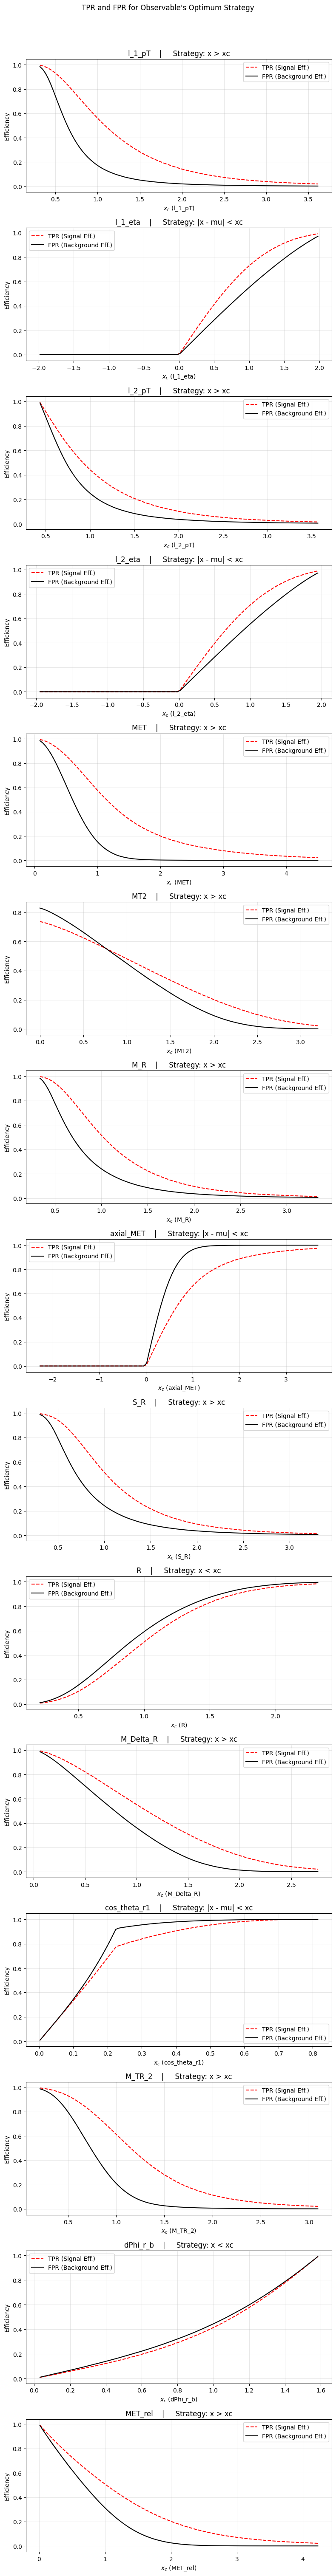

In [37]:
#filter the variables whose selection_strategy for a observable is not none and store it
variables_to_plot= [var for var in (RawNames + FeatureNames) if selection_strategy[var] is not None]

#Call the plotting function
plot_tpr_fpr(df, variables_to_plot, selection_strategy)

In [38]:
#Exercise 5.3

#Creating list of scenarios: (Number_of_signals, Number_of_background)
scenario=[
    (10,100),
    (100, 1000),
    (1000, 10000),
    (10000, 100000)
]


def plot_significance(df, varnames, selection_strategy, scenario):
    n= len(varnames)    #Number of observables
    fig, axes= plt.subplots(n, 1, figsize=(8, 4*n))
    
    ### DID THE SAME STEPS AS IN EXERCISE 5.2 FOR CREATING GRID, SKIPPING THE NONE STRATEGY, CONVERTING
    ### SIGNALS AND BACKGROUND VALUES INTO NUMPY ARRAY, AND CALLING THE  'compute_tpr_fpr' FUNCTION.
    for idx, var in enumerate(varnames):
        strategy= selection_strategy.get(var)
        if strategy is None:
            axes[idx].set_title(f"{var}- No Separation (Skipped)")
            continue
        
        signal_values= df_sig[var].to_numpy()
        background_values= df_bkg[var].to_numpy()
        
        xc_values, tpr, fpr= compute_tpr_fpr(signal_values, background_values, strategy)
        
        #Loop through each scenario
        for (NS, NB) in scenario:
            NS_prime= tpr*NS   #Using the formula provided in the problem. N_s'
            NB_prime= fpr*NB    #Using the formula providing in the problem calculate N_b'
            
            
            #Calculate the denominator for the main formula.
            denominator= np.sqrt(NB_prime + NS_prime)
            denominator[denominator==0]= np.nan    #If denominator is 0, replace it with a 'NotaNumber'
            
            #Calculate the significance
            significance= NS_prime/denominator
            
            #Make the plot
            axes[idx].plot(xc_values, significance, label= f"$N_s$: {NS} & $N_b$: {NB}")
        
        #Provide labes to x-axis and y-axis for corresponding subplot in the grid
        axes[idx].set_xlabel(f"$X_c$ ({var})")
        axes[idx].set_ylabel("Significance")
        
        #Set the legend for color representation
        axes[idx].legend()
        #Gives a title to the subplot corresponding to 'idx' in the grid
        axes[idx].set_title(f"{var}    |    Strategy: {strategy}")
        
        #Apply grid line
        axes[idx].grid(True, alpha=0.3)
    
    #Provide the overall title to the Plot
    plt.suptitle("Significance for each Observable Under Different Scenarios", y=1)
    plt.tight_layout()    #Prevents overalpping of plot and titles/labels
    plt.show()

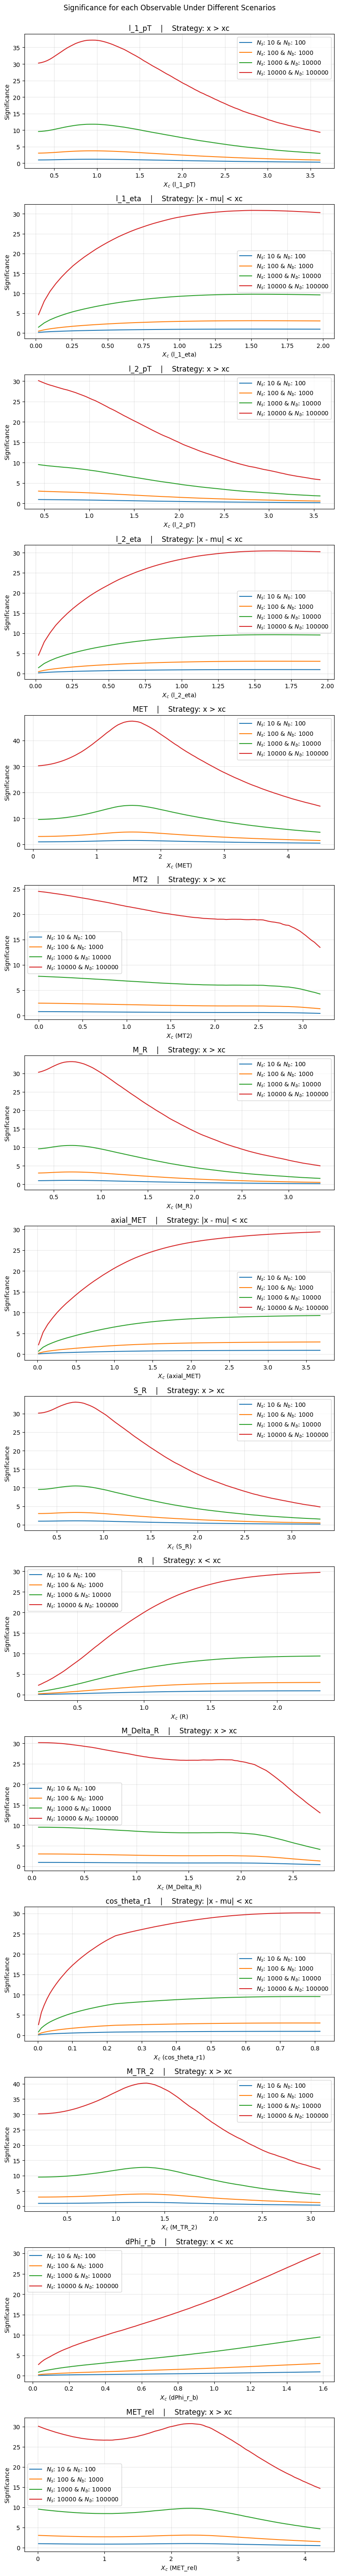

In [39]:
plot_significance(df, variables_to_plot, selection_strategy, scenario)

## Exercise 6: Cut Flow


### Exercise 6.1

For each above scenario, choose a subset (minumum 3) of observables to use for selections, and values of $x_c$ based on your significance plots (part 3c). 

### Exercise 6.2
Create a "cut-flow" table for each scenario where you successively make the selections on each observable and tabulate $\epsilon_S$, $\epsilon_B$, $N'_S$, $N'_B$, and $\sigma_{S'}$.

### Exercise 6.3
In 3c above you computed the significance for each observable assuming to make no other selections on any other observable. If the variables are correlated, then this assumption can lead to non-optimial results when selecting on multiple variables. By looking at the correlation matrices and your answers to 4b, identify where this effect could be most detrimental to the significance. Attempt to correct the issue by applying the selection in one observable and then optimizing (part 3c) for a second observable. What happens if you change the order of your selection (make selection on second and optimize on first)?




In [40]:
# Exercise 6.1

#List of tuples representing selected_variables
#Representation: (varable, optimal_strategy, significance)
selected_variables=[
    ("l_1_pT", "x > xc", 1.5),
    ("MET",       "x > xc", 1.5),
    ("M_Delta_R", "x > xc", 1.0),
]

In [42]:
def apply_cut(df, var, strategy, xc):
    mu= df[var].mean()   #Calculate the mean of corresponding variable
    
    
    ## RETURN THE DATAFRAME WHERE THE CORRESPONDING ATTRIBUTE(Var in this case) SATISFY THE OPTIMAL STRATEGY
    if strategy== "x > xc":
        return df[df[var] > xc]
    
    elif strategy== "x < xc":
        return df[df[var] < xc]
    
    elif strategy == "|x - mu| < xc":
        return df[np.abs(df[var]) < xc]
    
    elif strategy == "|x - mu| > xc":
        return df[np.abs(df[var]) > xc]

    
def cut_flow_table(df, selected_vars, NS, NB, label=""):
    signal_total= len(df_sig)    #No. of rows in signal dataframe
    background_total= len(df_bkg)    #No. of rows in background dataframe
    
    current_df= df.copy()    #Create a copy of the dataframe
    rows=[]
    
    signal_current= df[df['signal']==1]
    background_current= df[df['signal']==0]
    eps_signal= len(signal_current)/signal_total
    eps_background= len(background_current)/background_total
    
    NS_prime= eps_signal * NS
    NB_prime= eps_background * NB
    
    
    denominator= np.sqrt(NS_prime + NB_prime)
    
    sigma= NS_prime/denominator
    
    rows.append(["No cut", "-", "-",
                f"{eps_Signal:.3f}", f"{eps_Background:.3f}",
                 f"{NS_prime:.1f}", f"{NB_prime:.1f}", f"{sigma:.3f}"
                ])
    
    for var, strategy, xc in selected_vars:
        current_df= apply_cut(current_df, var, strategy, xc)
        
        signal_current= current_df[current_df["signal"]==1]
        background_current= current_df[current_df['signal']==0]
        
        eps_signal= len(signal_current)/signal_total
        eps_background= len(background_current)/backhround_total
        
        NS_prime= eps_signal*NS
        NB_prime= eps_background*NB
        
        denominator= np.sqrt(NS_prime + NB_prime)
        sigma= NS_prime/denominator
        
        rows.append([var, strategy, f"{xc:.2f}",
                    f"{eps_signal:.3f}", f"{eps_background:.3f}",
                     f"{NS_prime:.1f}", f"{NB_prime:.1f}", f"{sigma:.3f}"
                    ])
        
        headers= ["Variables", "Strategy", "$X_c$", "\\$epsilon_s$", 
                  "\\$epsilon_b", "$N'_s$", "$N'_b", "\\$sigma_(s')$"
                 ]
        
        print(f"\nCut-FLow Table 

SyntaxError: EOL while scanning string literal (1105126486.py, line 68)

In [43]:
def apply_cut(df, var, strategy, xc):
    mu= df[var].mean()   #Calculate the mean of corresponding variable
    
    
    ## RETURN THE DATAFRAME WHERE THE CORRESPONDING ATTRIBUTE(Var in this case) SATISFY THE OPTIMAL STRATEGY
    if strategy== "x > xc":
        return df[df[var] > xc]
    
    elif strategy== "x < xc":
        return df[df[var] < xc]
    
    elif strategy == "|x - mu| < xc":
        return df[np.abs(df[var] - mu) < xc]
    
    elif strategy == "|x - mu| > xc":
        return df[np.abs(df[var] - mu) > xc]

    
def cut_flow_table(df, selected_vars, NS, NB, label=""):
    signal_total= len(df[df['signal'] == 1])    #No. of rows in signal dataframe
    background_total= len(df[df['signal'] == 0])    #No. of rows in background dataframe
    
    current_df= df.copy()    #Create a copy of the dataframe
    rows=[]
    
    signal_current= df[df['signal']==1]   #Filter the dataframe where signals is 1
    background_current= df[df['signal']==0]    #Filter the dataframe where signals is 0
    eps_signal= len(signal_current)/signal_total     #Calculate efficiency value for signal
    eps_background= len(background_current)/background_total    #Calculate efficiency value for background
    
    NS_prime= eps_signal * NS    #Calculate the NS prime
    NB_prime= eps_background * NB    #Calculate the NS prime
    
    
    #Calculate denominator for significance
    denominator= np.sqrt(NS_prime + NB_prime)
    
    
    #Calculate sigma
    sigma= NS_prime/denominator
    
    
    #append a list into the rows. Format: [Variable, Strategy, X_c, efficiency_signal, efficiency_background, no_of_signals, No_of_background, significance] 
    rows.append(["No cut", "-", "-",
                f"{eps_signal:.3f}", f"{eps_background:.3f}",
                 f"{NS_prime:.1f}", f"{NB_prime:.1f}", f"{sigma:.3f}"
                ])
    
    #Loop through the selected variables
    for var, strategy, xc in selected_variables:
        
        #Create a new cut dataframe for the passed strategy, xc, and selected variables
        current_df= apply_cut(current_df, var, strategy, xc)
        
        #Filter the signals from current_df
        signal_current= current_df[current_df["signal"]==1]
        #Filter the backgrounds from current df
        background_current= current_df[current_df['signal']==0]
        
        
        #Calculate the efficiency for signal and background
        eps_signal= len(signal_current)/signal_total
        eps_background= len(background_current)/background_total
        
        
        #Calculate the NB_prime and NS_prime
        NS_prime= eps_signal*NS
        NB_prime= eps_background*NB
        
        denominator= np.sqrt(NS_prime + NB_prime)
        sigma= NS_prime/denominator
        
        #Append the calculated fields into into rows (using same format as above)
        rows.append([var, strategy, f"{xc:.2f}",
                    f"{eps_signal:.3f}", f"{eps_background:.3f}",
                     f"{NS_prime:.1f}", f"{NB_prime:.1f}", f"{sigma:.3f}"
                    ])
    #Header for the table
    headers = ["Variables", "Strategy", "Xc", 
           "ε_s", "ε_b", "N's", "N'b", "σ_s'"]
    
    #Print in readable tabular format.
    print(f"\nCut-FLow Table for $N_s$: {NS} and $N_b$: {NB}")
    display(HTML(tabulate.tabulate(rows, tablefmt="html", headers= headers)))

In [44]:
#Create a table for each scenario:
for NS, NB in scenario:
    cut_flow_table(df, selected_variables, NS, NB)


Cut-FLow Table for $N_s$: 10 and $N_b$: 100


Variables,Strategy,Xc,ε_s,ε_b,N's,N'b,σ_s'
No cut,-,-,1,1,10,100,0.953
l_1_pT,x > xc,1.50,0.284,0.052,2.8,5.2,1.005
MET,x > xc,1.50,0.139,0.005,1.4,0.5,1.007
M_Delta_R,x > xc,1.00,0.104,0.004,1,0.4,0.857



Cut-FLow Table for $N_s$: 100 and $N_b$: 1000


Variables,Strategy,Xc,ε_s,ε_b,N's,N'b,σ_s'
No cut,-,-,1,1,100,1000,3.015
l_1_pT,x > xc,1.50,0.284,0.052,28.4,51.6,3.179
MET,x > xc,1.50,0.139,0.005,13.9,5.1,3.186
M_Delta_R,x > xc,1.00,0.104,0.004,10.4,4.4,2.711



Cut-FLow Table for $N_s$: 1000 and $N_b$: 10000


Variables,Strategy,Xc,ε_s,ε_b,N's,N'b,σ_s'
No cut,-,-,1,1,1000,10000,9.535
l_1_pT,x > xc,1.50,0.284,0.052,284.4,515.9,10.053
MET,x > xc,1.50,0.139,0.005,139,51.3,10.075
M_Delta_R,x > xc,1.00,0.104,0.004,104.4,44,8.572



Cut-FLow Table for $N_s$: 10000 and $N_b$: 100000


Variables,Strategy,Xc,ε_s,ε_b,N's,N'b,σ_s'
No cut,-,-,1,1,10000,100000,30.151
l_1_pT,x > xc,1.50,0.284,0.052,2844.2,5159.3,31.792
MET,x > xc,1.50,0.139,0.005,1389.9,513.4,31.859
M_Delta_R,x > xc,1.00,0.104,0.004,1044.1,439.5,27.107


In [45]:
df.corr()

,signal,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi,MET_rel,axial_MET,M_R,M_TR_2,R,MT2,S_R,M_Delta_R,dPhi_r_b,cos_theta_r1
signal,1.000000,0.391075,0.000425,0.000433,0.196651,0.001426,0.000339,0.439725,-0.000590,0.283162,0.079145,0.270347,0.425832,0.109128,0.079766,0.261762,0.274235,0.032801,0.266836
l_1_pT,0.391075,1.000000,-0.000579,0.000112,0.683954,-0.000509,0.001076,0.382675,-0.001368,0.160428,-0.014196,0.851136,0.722754,-0.185501,-0.021114,0.810678,0.229309,-0.157454,0.164501
l_1_eta,0.000425,-0.000579,1.000000,-0.000854,-0.000249,0.406167,-0.001038,-0.002454,-0.000587,-0.001538,-0.001104,-0.000882,-0.001148,0.000639,0.000496,-0.000975,-0.001581,-0.001694,0.001629
l_1_phi,0.000433,0.000112,-0.000854,1.000000,0.002009,0.000249,-0.265777,0.000876,-0.184133,0.000793,-0.001864,0.001694,0.001492,0.000427,0.001232,0.002364,0.001443,0.002275,0.001312
l_2_pT,0.196651,0.683954,-0.000249,0.002009,1.000000,-0.000880,0.000239,0.139512,-0.002390,-0.000921,0.078480,0.796679,0.429772,-0.323567,-0.122958,0.798528,0.014056,-0.013480,-0.217138
l_2_eta,0.001426,-0.000509,0.406167,0.000249,-0.000880,1.000000,0.000439,0.000436,-0.000321,0.001216,-0.000752,-0.000967,0.000032,0.000679,0.001624,-0.001094,0.001072,-0.000701,0.001499
l_2_phi,0.000339,0.001076,-0.001038,-0.265777,0.000239,0.000439,1.000000,-0.000348,-0.035309,0.001624,-0.001792,0.001211,0.000874,0.001169,0.002625,0.001464,0.002124,-0.000552,0.000188
MET,0.439725,0.382675,-0.002454,0.000876,0.139512,0.000436,-0.000348,1.000000,-0.003193,0.704010,0.175867,0.264332,0.719661,0.457239,0.206420,0.306776,0.579022,0.382618,0.424855
MET_phi,-0.000590,-0.001368,-0.000587,-0.184133,-0.002390,-0.000321,-0.035309,-0.003193,1.000000,-0.005497,-0.000440,-0.002364,-0.002063,-0.000487,0.000097,-0.002757,-0.000913,-0.003912,0.000605
MET_rel,0.283162,0.160428,-0.001538,0.000793,-0.000921,0.001216,0.001624,0.704010,-0.005497,1.000000,-0.134441,0.078459,0.584388,0.594539,0.535318,0.149794,0.748284,0.377675,0.315743


`NOTE:` Since l2_pT and M_R are highly correlated with one another (\\$alpha$=0.79) we will be taking these variables into consideration. 

In [46]:
#Exercise 6.3

def optimize_xc(df, var, strategy, n_cuts=100):
    signal= df[df['signal']==1][var].to_numpy()   #Filter the signals and convert it into numpy array
    background= df[df['signal']==0][var].to_numpy()   #Filter the backgrounds and convert it into numpy array
    all_values= np.concatenate([signal, background])   #Create a single array of signal and background (using concatenation)
    xc_values= np.linspace(np.percentile(all_values, 1), np.percentile(all_values, 99), n_cuts)    #converts the 1st to 99th percentile of 'all_values' into n_cuts part
    mu= np.mean(all_values)    #Calculate the mean of all values.
    
    
    #Initially, set best threshold and significance as None and -infinity
    best_xc, best_sigma= None, -np.inf
    
    
     #Loop through the linearly separated thresholds
    for xc in xc_values:
        if strategy== "x > xc":   #If strategy is 'x > xc', compute the fraction of signal and background values greater than the threshold
            eps_signal = np.mean(signal > xc)
            eps_background = np.mean(background > xc)
        elif strategy == "x < xc":   #If strategy is 'x < xc', compute the fraction of signal and background values smaller than the threshold
            eps_signal = np.mean(signal < xc)
            eps_background = np.mean(background < xc)
        elif strategy == "|x - mu| < xc":   #If strategy is '|x - mu| < xc', compute the fraction of signal and background values whose absolute deviation from the mean is smaller than the threshold
            eps_signal = np.mean(np.abs(signal - mu) < xc)
            eps_background = np.mean(np.abs(background - mu) < xc)
        
        NS_prime= eps_signal * 1000     #Compute the effective number of signal events after applying the cut
        NB_prime= eps_background * 1000    #Compute the effective number of background events after applying the cut
        denominator= np.sqrt(NS_prime + NB_prime)    #Compute the denominator of the significance formula
        sigma = NS_prime/denominator    #Compute the significance for this threshold
        
        if sigma > best_sigma:    #If new threshould > best threshold, replace the best with currently computed one
            best_sigma= sigma
            best_xc= xc
    return best_xc, best_sigma

In [47]:
#Order 1: Cut l_2_pT first, then optimize M_R
print("Order 1: Cut l_2_pT first, then optimize M_R")

xc_l2pT, _ = optimize_xc(df, "l_2_pT", "x > xc")    #Find the optimal threshold for l_2_pT with no prior cut
print(f"Optimal xc for l_2_pT (No prior cut): {xc_l2pT:.3f}   (sigma= {_:.3f})")

df_after_l2pT= apply_cut(df, "l_2_pT", "x > xc", xc_l2pT)    #Apply the optimal l_2_pT cut to dataframe
xc_MR_after, sigma_after= optimize_xc(df_after_l2pT, "M_R", "x > xc")    #Re-optimize the threshold for M_R on the post-cut dataframe
print(f"Optimal xc for M_R after l_2_pT cut: {xc_MR_after:.3f}  (Sigma= {sigma_after:.3f})")

Order 1: Cut l_2_pT first, then optimize M_R
Optimal xc for l_2_pT (No prior cut): 0.435   (sigma= 22.299)
Optimal xc for M_R after l_2_pT cut: 0.523  (Sigma= 22.760)


In [49]:
# Order 2:
print("Order 2: Cut M_R first, then optimize l_2_pT")
xc_MR, _ = optimize_xc(df, "M_R", "x > xc")
print(f"Optimal xc for M_R (no prior cut): {xc_MR:.3f}")    #Find the optimal threshold for M_R with no prior cut

df_after_MR = apply_cut(df, "M_R", "x > xc", xc_MR)    #Apply the optimal M_R cut to dataframe
xc_l2pT_after, sig_after2 = optimize_xc(df_after_MR, "l_2_pT", "x > xc")    #Re-optimize the threshold for l_2_pT on the post-cut dataframe
print(f"Optimal xc for l_2_pT after M_R cut: {xc_l2pT_after:.3f}  (sigma={sig_after2:.3f})")

Order 2: Cut M_R first, then optimize l_2_pT
Optimal xc for M_R (no prior cut): 0.519
Optimal xc for l_2_pT after M_R cut: 0.441  (sigma=22.238)


`l_2_pT` and `M_R`are correlated variables. When optimizing them independently the optimal xc for each is 0.435 and 0.519 respectively. However, when a cut is applied first, the optimal xc of the second variable shifts. This shows the effect of correlation.

The final significance also depends on cut order. In our case, cutting `l_2_pT` first then optimizing `M_R` gave **sigma = 22.760**, while the reverse order have **sigma =  22.238**. This shows that the single variable optimization (the one we applied in problem 3c.) is not perfectly optimal for correlated variables, and the order of cut matters.

## Exercise 7: ROC Curves

### Exercise 7.1
For the top 3 observables you identified earlier, create one figure overlaying the Reciever Operating Characteristic (ROC) curves for the 3 observables. Compute the area under the curves and report it in the legend of the figure.

### Exercise 7.2
Write a function that you can use to quickly create the figure in part a with other observables and different conditions. Note that you will likely revise this function as you do the remainder of the lab.

### Exercise 7.3
Use the function from part b to compare the ROC curves for the successive selections in lab 3, exercise 4. Specifically, plot the ROC curve after each selection.

### Exercise 7.4
Use your function and appropriate example to demonstrate the effect (if any) of changing order of the successive selections.



In [50]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [51]:
from sklearn.metrics import roc_curve, auc

In [52]:
#Exercise 7.1
variables= ["l_1_pT", "MET", "M_Delta_R"]    #Top 3 variables selected based on highest significance from exercise 3c

def compute_roc(df, var, strategy):
    y_true= df["signal"].to_numpy()    #Extract the true labels (1 for signal, 0 for background) and convert to numpy array
    score= df[var].to_numpy()    #Extract the observable values for the given variable and convert to numpy array
    
    if strategy== "x < xc":    #If strategy is 'x < xc', flip the score so that higher score still means more signal like
        score = -score
    elif strategy== "|x - mu| < xc":    #If strategy is '|x - mu| < xc', compute the absolute deviation from the mean so that smaller deviation means more signal like
        mu= np.mean(score)
        score= -np.abs(score-mu)    
    
    fpr, tpr, _ = roc_curve(y_true, score)    #Compute the ROC curve (false positive rate, true positive rate) using sklearn
    auc_score= auc(fpr, tpr)    #Compute the Area Under the Curve (AUC) - higher AUC means better discrimination between signal and background
    return fpr, tpr, auc_score    #Return the ROC curve and AUC score

In [53]:
# Exercise 7.2 
def plot_roc_curve(df, varnames, selection_strategy, title="ROC Curves"):
    fig, ax= plt.subplots(figsize=(8,6))    #Create a figure and axis for the ROC curve plot
    
    for var in varnames:    #Loop through each variable and plot its ROC curve
        strategy= selection_strategy.get(var, "x > xc")    #Get the selection strategy for the variable, defaulting to 'x > xc' if not found
        fpr, tpr, auc_score= compute_roc(df, var, strategy)    #Compute the ROC curve and AUC score for the variable
        ax.plot(fpr, tpr, label= f"{var} (AUC= {auc_score:.3f})")    #Plot the ROC curve with the AUC score in the legend
        
    ax.plot([0,1], [0,1], 'k--', label= "Random (AUC= 0.5)")    #Plot the diagonal random classifier baseline for reference
        
    ax.set_xlabel("False Positive Rate (Background Efficiency)")    #Label x-axis as false positive rate
    ax.set_ylabel("True Positive Rate (Signal Efficiency)")    #Label y-axis as true positive rate
    ax.set_title(title)    #Set the title of the plot
    ax.legend(fontsize=8)    #Add legend with smaller font to avoid overlap
    ax.grid(True, alpha=0.3)    #Add a light grid for readability
    plt.tight_layout()
    plt.show()

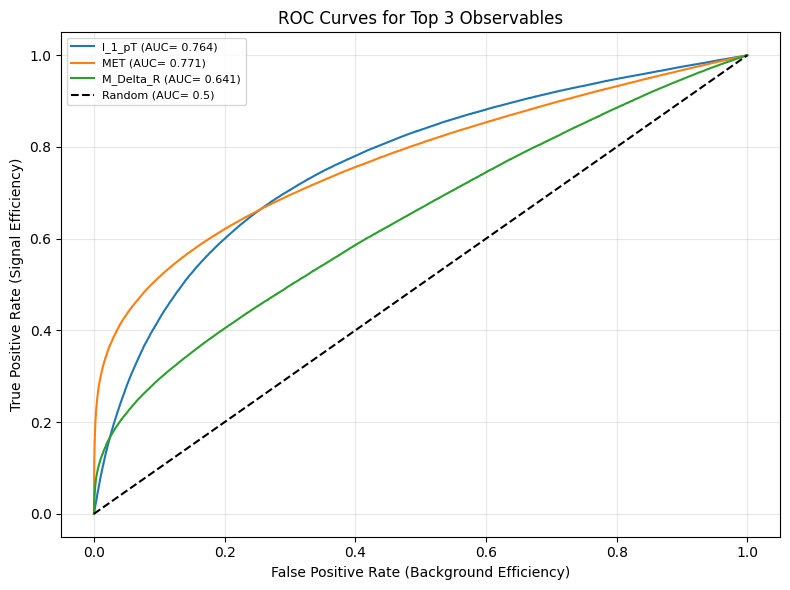

In [54]:
plot_roc_curve(df, variables, selection_strategy, title="ROC Curves for Top 3 Observables")

In [55]:
#Exercise 7.3
def plot_roc_after_cuts(df, selected_vars, roc_var, selection_strategy):
    fig, ax= plt.subplots(figsize=(8,6))
    
    roc_strategy= selection_strategy.get(roc_var, "x > xc")    #Get the strategy for roc_var separately to avoid overwriting
    fpr, tpr, auc_score= compute_roc(df, roc_var, roc_strategy)
    ax.plot(fpr, tpr, label= f"No cut (AUC= {auc_score:.3f})")    #Bug 1 fixed - 'cit' -> 'cut'
    
    #Applying cut one by one and recomputing ROC
    current_df= df.copy()
    for i, (var, cut_strategy, xc) in enumerate(selected_vars):    #Bug 3 fixed - renamed to cut_strategy
        current_df= apply_cut(current_df, var, cut_strategy, xc)
        
        if roc_var== var:
            continue
        
        fpr, tpr, auc_score= compute_roc(current_df, roc_var, roc_strategy)    #Bug 3 fixed - uses roc_strategy
        ax.plot(fpr, tpr, label= f"After cut {i+1} on {var} (AUC= {auc_score:.3f})")    #Bug 2 fixed - i+1 and actual var name
    
    ax.plot([0,1], [0,1], "k--", label="Random (AUC=0.5)")
    ax.set_xlabel("False Positive Rate (Background Efficiency)")
    ax.set_ylabel("True Positive Rate (Signal Efficiency)")
    ax.set_title(f"ROC for {roc_var} after successive cuts")
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

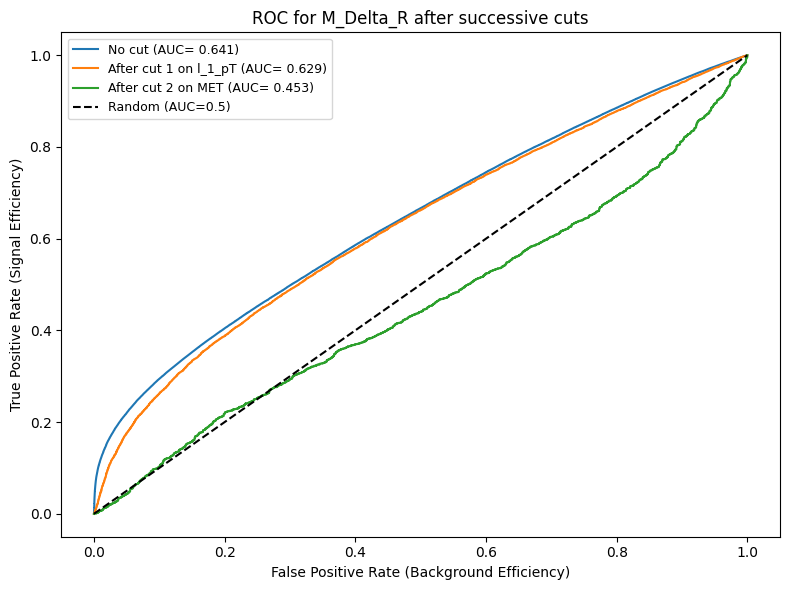

In [56]:
#Plotting:
selected_variables=[
    ("l_1_pT", "x > xc", 1.5),
    ("MET",       "x > xc", 1.5),
    ("M_Delta_R", "x > xc", 1.0),
]
plot_roc_after_cuts(df, selected_variables, "M_Delta_R", selection_strategy)

In [57]:
# Exercise 7.4
def plot_roc_cut_order(df, var_A, strat_A, xc_A, var_B, strat_B, xc_B, roc_var, selection_strategy):
    fig, ax= plt.subplots(figsize=(8,6))    #Create a figure and axis for the ROC curve plot
    
    strategy= selection_strategy.get(roc_var, "x > xc")    #Get the selection strategy for roc_var, defaulting to 'x > xc' if not found
    
    #Baseline - compute and plot ROC for roc_var with no cuts applied
    fpr, tpr, auc_score= compute_roc(df, roc_var, strategy)
    ax.plot(fpr, tpr, 'k--', label=f"No cut (AUC={auc_score:.3f})")
    
    # Order 1: Cut on var_A first, then var_B, and compute ROC for roc_var
    df_order1= apply_cut(df, var_A, strat_A, xc_A)    #Apply cut on var_A
    df_order1= apply_cut(df_order1, var_B, strat_B, xc_B)    #Apply cut on var_B to the already cut dataframe
    fpr, tpr, auc_score = compute_roc(df_order1, roc_var, strategy)    #Recompute ROC after both cuts
    ax.plot(fpr, tpr, label=f"Order 1: {var_A} -> {var_B}  (AUC={auc_score:.3f})")
    
    # Order 2: Cut on var_B first, then var_A, and compute ROC for roc_var
    df_order2 = apply_cut(df, var_B, strat_B, xc_B)    #Apply cut on var_B
    df_order2 = apply_cut(df_order2, var_A, strat_A, xc_A)    #Apply cut on var_A to the already cut dataframe
    fpr, tpr, auc_score = compute_roc(df_order2, roc_var, strategy)    #Recompute ROC after both cuts
    ax.plot(fpr, tpr, label=f"Order 2: {var_B} -> {var_A}  (AUC={auc_score:.3f})")
    
    ax.plot([0, 1], [0, 1], color='gray', linestyle=':')    #Plot the diagonal random classifier baseline for reference
    #Label x and y axis
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(f"ROC for {roc_var} — Cut Order Comparison")    #Set the title of plot
    ax.legend(fontsize=9)    #Add legend for representing cut 
    ax.grid(True, alpha=0.3)    #Add a light grid for readability
    plt.tight_layout()
    plt.show()

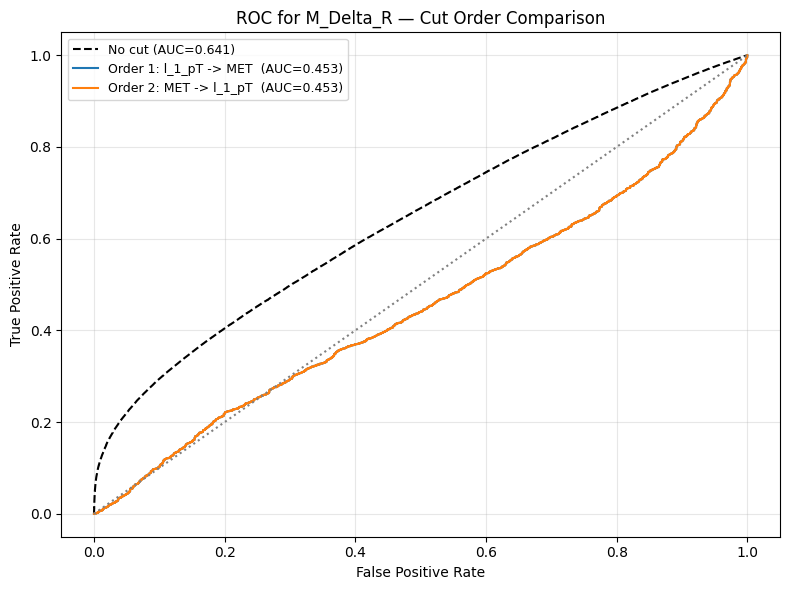

In [58]:
plot_roc_cut_order(
    df,
    var_A="l_1_pT", strat_A="x > xc", xc_A=1.5,
    var_B="MET",    strat_B="x > xc", xc_B=1.5,
    roc_var="M_Delta_R",
    selection_strategy=selection_strategy
)

## Exercise 8: Linear Discriminant

### Exercise 8.1

Using numpy, compute the between-class $\bf{S}_B$ and within-class $\bf{S}_W$ covariance matrices defined as:

$$
\bf{S}_B = (\bf{m_2}-\bf{m_1})(\bf{m_2}-\bf{m_1})^T \\
$$
$$
\bf{S}_W = \sum_{i=1,2} \sum_{n=1}^{l_i} (\bf{x}_n^i - \bf{m}_i) (\bf{x}_n^i - \bf{m}_i)^T
$$

where $\bf{m_i}$ are the vectors containing the means for category 1 and 2, here defined as signal and background. Here $\bf{x}_n^i$ is the vector containing the observables for the $n$th example event in category $i$.

### Exercise 8.2

Compute the linear coefficients $\bf{w} = \bf{S_W}^{-1}(\bf{m_2}-\bf{m_1})$. Compare the histogram of the distribution of $F_n^i=\bf{w}^T\bf{x}_n^i$ for the two categories.

### Exercise 8.3

Draw the ROC curve for $F_n$. 

### Exercise 8.4

What is the maximal significance you can obtain in the scenarios in exercise 5? 

In [59]:
# Exercise 8.1
all_vars= RawNames + FeatureNames

signal= df_sig[all_vars].to_numpy()    #Extract all variables for signal and convert to numpy array
background= df_bkg[all_vars].to_numpy()    #Extract all variables for background and convert to numpy array

m1= np.mean(background, axis=0)    #Compute the mean of each variable across all background
m2= np.mean(signal, axis=0)    #Compute the mean of each variable across all signal

diff = (m2-m1).reshape(-1,1)    #Compute the difference between signal and background means and reshape into a column vector
S_B= diff @ diff.T    #Compute the between-class scatter matrix as the outer product of the mean difference vector

def scatter_matrix(X, m):
    X_centered= X-m    #Center the data by subtracting the class mean from each event
    return X_centered.T @ X_centered    #Compute the within-class scatter matrix as X_centered^T @ X_centered

S_W= scatter_matrix(background, m1) + scatter_matrix(signal, m2)    #Compute the total within-class scatter matrix as the sum of background and signal scatter matrices

print(f"S_W shape: {S_W.shape}")    #Print the shape of the within-class scatter matrix to verify dimensions
print(f"\n\nS_B diagonal (variance between classes): \n\n{np.diag(S_B)}")    #Print the diagonal of S_B which shows the between-class variance for each variable

S_W shape: (18, 18)


S_B diagonal (variance between classes): 

[2.87970231e-01 7.31359210e-07 7.58848582e-07 6.62743950e-02
 8.24285333e-06 4.65416020e-07 5.93638731e-01 1.40737661e-06
 1.89041884e-02 1.15445419e-01 2.53650781e-02 1.05428264e-01
 1.06282002e-02 1.17716603e-01 1.11356721e-02 2.46737249e-01
 8.24165940e-04 2.55286317e-01]



Linear discriminant weights w:
l_1_pT         : 0.000002
l_1_eta        : 0.000000
l_1_phi        : 0.000000
l_2_pT         : 0.000001
l_2_eta        : 0.000000
l_2_phi        : 0.000000
MET            : 0.000002
MET_phi        : 0.000000
MT2            : -0.000000
M_R            : -0.000000
axial_MET      : 0.000000
S_R            : -0.000002
R              : -0.000002
M_Delta_R      : 0.000002
cos_theta_r1   : 0.000005
M_TR_2         : 0.000000
dPhi_r_b       : -0.000000
MET_rel        : 0.000000


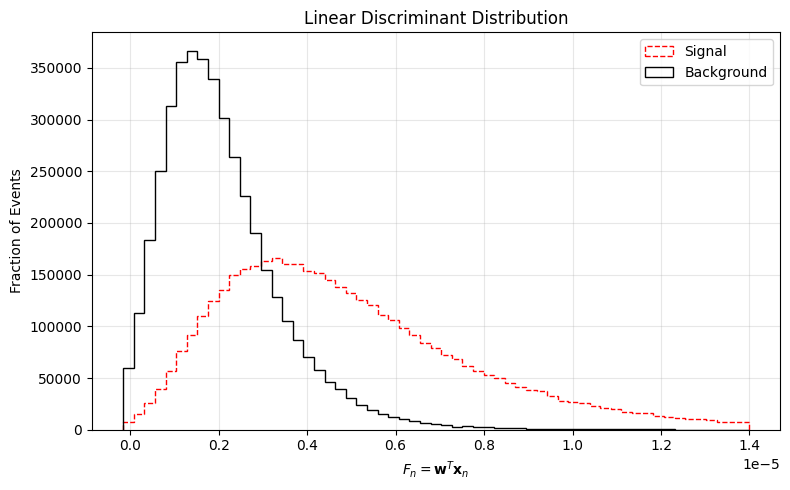

In [60]:
# Exercise 8.2
S_W_inv= np.linalg.inv(S_W)    #Compute the inverse of the within-class scatter matrix
w= S_W_inv @ (m2-m1)    #Compute the Linear Discriminant weights as S_W^-1 * (m2 - m1)

print(f"\nLinear discriminant weights w:")
for var, wi in zip(all_vars, w):
    print(f"{var:15s}: {wi:.6f}")    #Print the weight of each variable in the linear discriminant

#Compute discriminant score F_n = w^T x_n for each event
X_sig= df[df["signal"]==1][all_vars].to_numpy()    #Extract all variables for signal events and convert to numpy array
X_bkg= df[df["signal"]==0][all_vars].to_numpy()    #Extract all variables for background events and convert to numpy array
F_sig= X_sig @ w    #Compute the discriminant score for each signal event (shape: n_sig,)
F_bkg= X_bkg @ w    #Compute the discriminant score for each background event (shape: n_bkg,)

# Plot distributions of F_n for signal and background
fig, ax= plt.subplots(figsize=(8,5))

#Use percentile range to avoid outliers dominating the plot
x_min= np.percentile(np.concatenate([F_sig, F_bkg]), 1)    #Set the lower bound of the plot to the 1st percentile
x_max= np.percentile(np.concatenate([F_sig, F_bkg]), 99)    #Set the upper bound of the plot to the 99th percentile
bins= np.linspace(x_min, x_max, 60)    #Create 60 equally spaced bins between the lower and upper bounds

ax.hist(F_sig, bins=bins, density=True, histtype='step', color='red', linestyle='--', label="Signal")    #Plot the signal discriminant score distribution
ax.hist(F_bkg, bins=bins, density=True, histtype='step', color='black', label="Background")    #Plot the background discriminant score distribution
ax.set_xlabel("$F_n = \\mathbf{w}^T \\mathbf{x}_n$")    #Label x-axis as the discriminant score
ax.set_ylabel("Fraction of Events")    #Label y-axis as the fraction of events
ax.set_title("Linear Discriminant Distribution")    #Set the title of the plot
ax.legend()
ax.grid(True, alpha=0.3)    #Add a light grid for readability
plt.tight_layout()
plt.show()

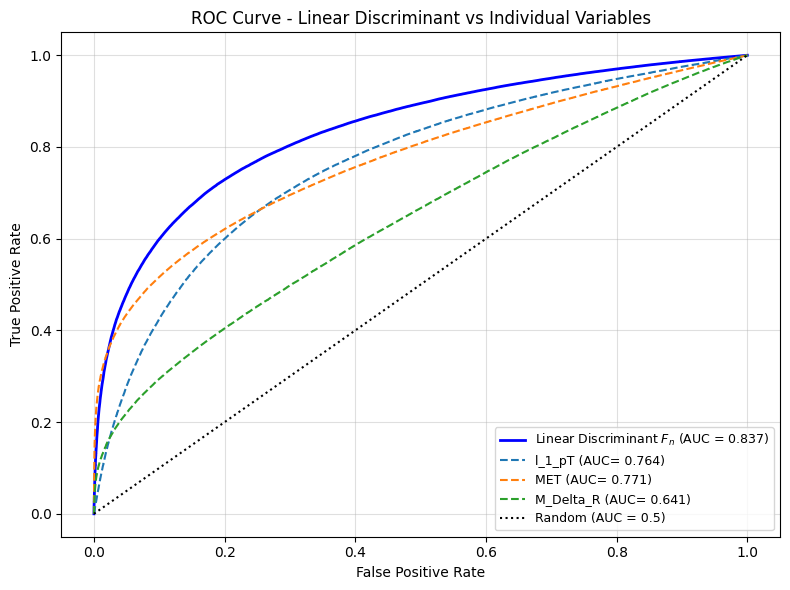

In [61]:
# Exercise 8.3
# Build full score array and true labels
F_all= np.concatenate([F_sig, F_bkg])    #Combine signal and background discriminant scores into a single array
y_true= np.concatenate([np.ones(len(F_sig)), np.zeros(len(F_bkg))])    #Create true labels - 1 for signal, 0 for background

fpr, tpr, _ = roc_curve(y_true, F_all)    #Compute the ROC curve for the linear discriminant score
auc_score= auc(fpr, tpr)    #Compute the AUC score for the linear discriminant

fig, ax = plt.subplots(figsize=(8,6))
ax.plot(fpr, tpr, color='blue', linewidth=2, label=f"Linear Discriminant $F_n$ (AUC = {auc_score:.3f})")    #Plot the linear discriminant ROC curve

for var in variables:    #Loop through each individual variable and plot its ROC curve for comparison
    strategy= selection_strategy.get(var, "x > xc")    #Bug fixed - added missing space in default strategy
    fpr_v, tpr_v, auc_v= compute_roc(df, var, strategy)    #Compute the ROC curve for the individual variable
    ax.plot(fpr_v, tpr_v, linestyle='--', label=f"{var} (AUC= {auc_v:.3f})")    #Plot as dashed line to distinguish from linear discriminant

ax.plot([0,1], [0,1], 'k:', label="Random (AUC = 0.5)")    #Plot the diagonal random classifier baseline for reference
ax.set_xlabel("False Positive Rate")    #Label x-axis as false positive rate
ax.set_ylabel("True Positive Rate")    #Label y-axis as true positive rate
ax.set_title("ROC Curve - Linear Discriminant vs Individual Variables")    #Set title comparing linear discriminant to individual variables
ax.legend(fontsize=9)    #Add legend to distinguish the curves
ax.grid(True, alpha=0.4)    #Add a light grid for readability
plt.tight_layout()
plt.show()


Maximal Significance using Linear Discriminant F_n:
Scenario                     Best xc    Max sigma
--------------------------------------------------
NS=10    , NB=100           xc=   0.000       sigma=   1.532
NS=100   , NB=1000          xc=   0.000       sigma=   4.844
NS=1000  , NB=10000         xc=   0.000       sigma=  15.319
NS=10000 , NB=100000        xc=   0.000       sigma=  48.444


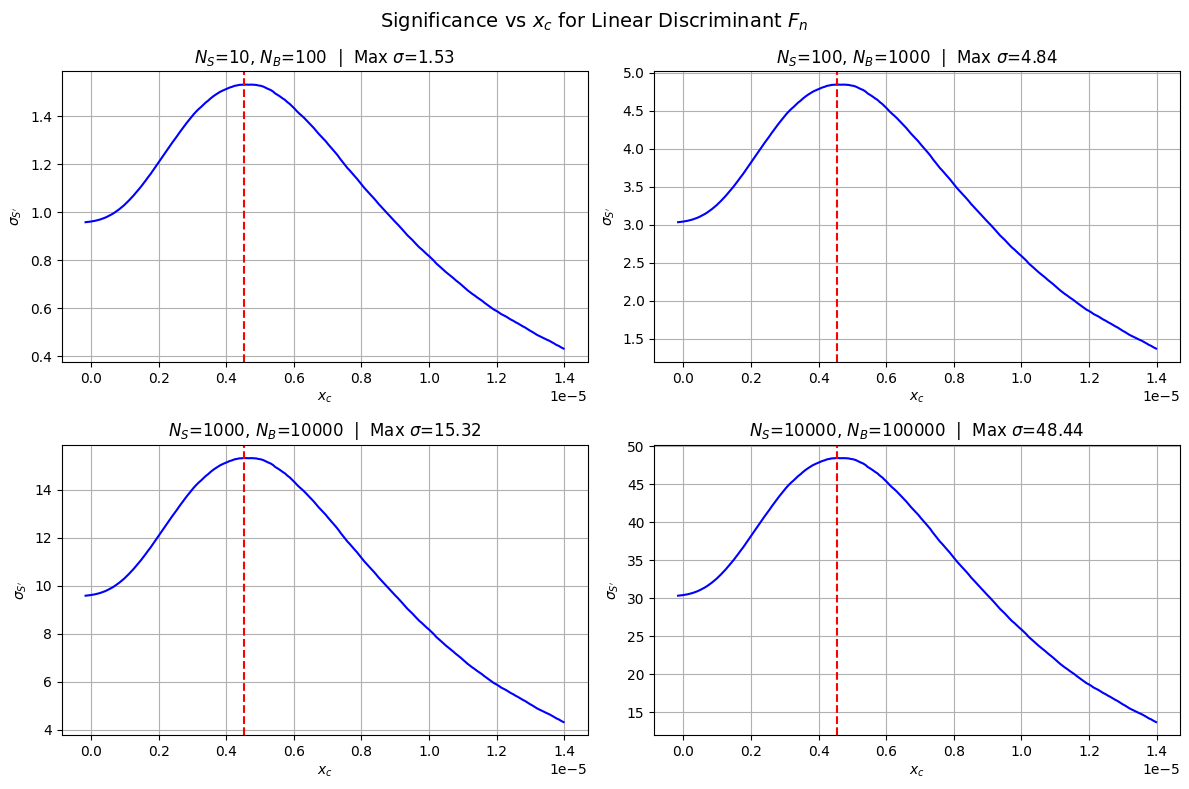

In [62]:
# Exercise 8.4
print("\nMaximal Significance using Linear Discriminant F_n:")
print(f"{'Scenario':<25} {'Best xc':>10} {'Max sigma':>12}")
print("-"*50)

xc_values= np.linspace(np.percentile(F_all, 1), np.percentile(F_all, 99), 200)    #Create 200 equally spaced threshold values between the 1st and 99th percentile of all discriminant scores

fig, axes= plt.subplots(2,2, figsize=(12, 8))    #Create grid of plots, one for each scenario (2 by 2)
axes= axes.flatten()    # Flatten the 2x2 grid into a 1D array for easy indexing

for idx, (NS, NB) in enumerate(scenario):    #Loop through each scenario (different NS and NB values)
    significances= []    # Empty list to store significance values for each threshold
    
    for xc in xc_values:    # loop through each threshold value and compute the significance
        eps_S= np.mean(F_sig > xc)    # Fraction of signal events passing the cut
        eps_B = np.mean(F_bkg > xc)    #Fraction of background events passing the cut
        NS_prime= eps_S*NS    # Effective number of signal events after cut
        NB_prime= eps_B*NB    # Effective number of background events after cut
        denom = np.sqrt(NS_prime + NB_prime)    #Denominator of the significance formula
        sigma= NS_prime/denom if denom>0 else 0    #Compute significance, avoiding division by zero
        significances.append(sigma)
    
    significances= np.array(significances)    #Convert significance list to numpy array
    best_idx= np.argmax(significances)    #Find the index of the threshold with the highest significance
    best_xc= xc_values[best_idx]    #Get the threshold value with the highest significance
    max_sigma= significances[best_idx]    #Get the highest significance value
    print(f"NS={NS:<6}, NB={NB:<8}      xc={best_xc:>8.3f}       sigma={max_sigma:>8.3f}")
    
    axes[idx].plot(xc_values, significances, color='blue')    #Plot significance vs threshold
    axes[idx].axvline(best_xc, color='red', linestyle='--', label= f"Best $x_c$={best_xc:.2f}")    #Mark the best threshold with a vertical red dashed line
    axes[idx].set_xlabel("$x_c$")
    axes[idx].set_ylabel("$\\sigma_{S'}$")
    axes[idx].set_title(f"$N_S$={NS}, $N_B$={NB}  |  Max $\\sigma$={max_sigma:.2f}")
    axes[idx].grid()

plt.suptitle("Significance vs $x_c$ for Linear Discriminant $F_n$ ", fontsize=14)    #Set overall title for the figure
plt.tight_layout()
plt.show()

The maximum significance that could be obtained for different scenarios are:

    NS=10    , NB=100                 sigma=   1.532
    NS=100   , NB=1000                sigma=   4.844
    NS=1000  , NB=10000               sigma=  15.319
    NS=10000 , NB=100000              sigma=  48.444

`NOTE:` AI was used to understand and implement problem number 7 and 8 efficiently.